# Simulación del arreglo experimental — v2

Reconstruyo la simulación de a poco, empezando por el primer filtro (RC-RC, etapa ambiente).

Idea: en vez de escribir una fórmula cerrada distinta para cada caso (sin carga, con carga, diferencial...), modelo el **circuito físico real** con sus variables de estado (las tensiones en los capacitores). Con ese modelo único puedo calcular *cualquier cosa*: respuesta en frecuencia, respuesta en el tiempo, agregar ruido, conectarlo con otra etapa, etc. Así puedo ir agrandando esto hacia el arreglo experimental completo sin reescribir todo de nuevo cada vez.

## Paso 1: el circuito RC-RC como sistema de estados

**El circuito:** `Vin --[R1]-- nodo A --[R2]-- nodo B (salida)`, con un capacitor `C1` de A a masa y `C2` de B a masa. Es el mismo circuito de la tesis (dos secciones RC en cascada, sin buffer entre ellas, por eso la segunda etapa carga a la primera).

**Las variables de estado** son las tensiones en los capacitores, $V_A$ y $V_B$, porque son las que "recuerdan" la historia del sistema (no pueden cambiar instantáneamente).

Planteo Kirchhoff de corrientes en cada nodo (llamo $\tau = RC$):

Nodo A: la corriente que entra por R1 menos la que sale por R2 carga a C1:

$$C\,\frac{dV_A}{dt} = \frac{V_{in}-V_A}{R} - \frac{V_A-V_B}{R}$$

Nodo B (sin carga a la salida todavía): la corriente que entra por R2 carga a C2:

$$C\,\frac{dV_B}{dt} = \frac{V_A-V_B}{R}$$

Reordenando, esto se escribe como un sistema lineal $\dot{x} = Ax + Bu$, $y = Cx$, con $x=(V_A,V_B)$, $u=V_{in}$, $y=V_B$:

$$\dot x = \begin{pmatrix}-2/\tau & 1/\tau \\ 1/\tau & -1/\tau\end{pmatrix} x + \begin{pmatrix}1/\tau \\ 0\end{pmatrix} u$$

Esto es lo que `scipy.signal` llama un sistema `StateSpace`. La ventaja de escribirlo así (en vez de ir directo a la función transferencia $H(s)$, que fue mi primer intento) es que le puedo pedir a scipy: función transferencia, simulación en el tiempo, combinarlo con otros sistemas, etc. Es el modelo físico, no un atajo algebraico.

In [226]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal, optimize

try:
    from IPython.display import display
except ImportError:
    display = print

K_B = 1.380649e-23  # J/K

# Tabla 5.1 de la tesis de Fran: seis canales del primer filtro (etapa ambiente)
CANALES = pd.DataFrame({
    "canal": [1, 2, 3, 4, 5, 6],
    "R_ohm": [150.0, 150.0, 51.0, 51.0, 15.0, 15.0],
    "C_uF": [2.2, 1.0, 2.2, 1.0, 2.2, 1.0],
    "fc_tesis_Hz": [180.0, 396.0, 530.0, 1165.0, 1801.0, 3962.0],
})

CANALES

,canal,R_ohm,C_uF,fc_tesis_Hz
0,1,150.0,2.2,180.0
1,2,150.0,1.0,396.0
2,3,51.0,2.2,530.0
3,4,51.0,1.0,1165.0
4,5,15.0,2.2,1801.0
5,6,15.0,1.0,3962.0


In [227]:
def sistema_rc_rc(R_ohm, C_F):
    """Modelo de estados de una linea RC-RC sin carga a la salida.

    Estados: x = [V_A, V_B] (tension en cada capacitor).
    Entrada: V_in. Salida: V_B.
    """
    tau = R_ohm * C_F
    A = np.array([
        [-2.0/tau,  1.0/tau],
        [ 1.0/tau, -1.0/tau],
    ])
    B = np.array([[1.0/tau], [0.0]])
    C_out = np.array([[0.0, 1.0]])
    D = np.array([[0.0]])
    return signal.StateSpace(A, B, C_out, D)


def ganancia_en(sistema, frecuencia_Hz):
    """Modulo de la respuesta en frecuencia H(jw) = C (jwI - A)^-1 B + D, a una frecuencia [Hz].

    La calculamos resolviendo el sistema lineal directamente en vez de
    convertir a funcion transferencia (signal.freqresp hace esa conversion
    internamente, y con R y C tan distintos entre canales los coeficientes
    del polinomio quedan mal condicionados numericamente).
    """
    s = 1j * 2.0 * np.pi * frecuencia_Hz
    n_estados = sistema.A.shape[0]
    H = sistema.C @ np.linalg.solve(s*np.eye(n_estados) - sistema.A, sistema.B) + sistema.D
    return np.abs(H.item())


def frecuencia_de_corte(sistema):
    """Frecuencia donde la ganancia cae a 1/sqrt(2) (-3.01 dB) de la ganancia en DC."""
    ganancia_DC = ganancia_en(sistema, 1e-4)
    objetivo = ganancia_DC / np.sqrt(2.0)
    return optimize.brentq(lambda f: ganancia_en(sistema, f) - objetivo, 1e-3, 1e7)


# Validamos el modelo contra los seis canales de la tesis
resultados = CANALES.copy()
sistemas = [sistema_rc_rc(fila.R_ohm, fila.C_uF*1e-6) for fila in resultados.itertuples()]
resultados["fc_modelo_Hz"] = [frecuencia_de_corte(s) for s in sistemas]
resultados["diferencia_%"] = 100.0*(resultados["fc_modelo_Hz"]-resultados["fc_tesis_Hz"])/resultados["fc_tesis_Hz"]

display(resultados.round({"fc_modelo_Hz": 2, "diferencia_%": 3}))

,canal,R_ohm,C_uF,fc_tesis_Hz,fc_modelo_Hz,diferencia_%
0,1,150.0,2.2,180.0,180.49,0.273
1,2,150.0,1.0,396.0,397.08,0.273
2,3,51.0,2.2,530.0,530.86,0.161
3,4,51.0,1.0,1165.0,1167.88,0.247
4,5,15.0,2.2,1801.0,1804.91,0.217
5,6,15.0,1.0,3962.0,3970.80,0.222


Las diferencias dan menores al 0.3% contra los valores de la Tabla 5.1 — igual que con la fórmula cerrada de mi primer intento, porque el modelo de estados representa el mismo circuito físico, solo que ahora scipy lo puede simular de verdad (no solo evaluar una fórmula).

Buena costumbre: cuando cambio de método, primero reviso que dé lo mismo que antes en el caso simple, antes de confiar en él para casos nuevos.

## Paso 2: simulación en el tiempo (ahora sí, como un osciloscopio)

Hasta acá, todo lo que hice fue preguntarle al sistema "en régimen permanente (sinusoidal, eterno), ¿cuánto atenuás a esta frecuencia?" — eso es análisis en frecuencia, es álgebra.

Ahora integro la ecuación diferencial en el tiempo: le doy una señal de entrada $V_{in}(t)$ real (un escalón, una senoidal) y calculo cómo evoluciona $V_A(t)$ y $V_B(t)$ instante a instante. Es lo que pasaría en la práctica si conectara el filtro real y lo mirara con un osciloscopio.

Uso `scipy.signal.lsim`, que resuelve $\dot{x}=Ax+Bu$ dado un vector de tiempo y de entrada — reutilizo el mismo `sistema_rc_rc` del Paso 1, sin redefinir nada.

Canal 1: R = 150 ohm, C = 2.20 uF, tau = R*C = 330.0 us, fc = 180.49 Hz


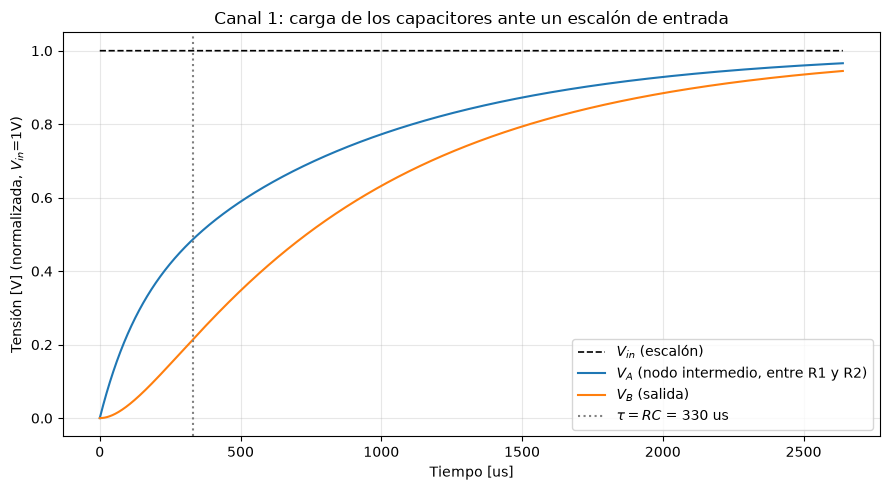

In [228]:
### 2.1 Respuesta al escalón: ver a los capacitores cargarse

# Trabajo con el canal 1 (mismo de la Tabla 5.1)
fila_canal1 = CANALES.loc[CANALES["canal"] == 1].iloc[0]
R = float(fila_canal1.R_ohm)
C = float(fila_canal1.C_uF) * 1e-6
tau = R * C
sistema = sistema_rc_rc(R, C)
fc = frecuencia_de_corte(sistema)

print(f"Canal 1: R = {R:.0f} ohm, C = {C*1e6:.2f} uF, tau = R*C = {tau*1e6:.1f} us, fc = {fc:.2f} Hz")

# Prendo un escalon de 1V en t=0 (los capacitores arrancan descargados, V_A=V_B=0)
fs_hz = 2_000_000.0  # resolucion numerica de la simulacion, no es un parametro fisico
duracion_s = 8 * tau
t = np.arange(0, duracion_s, 1.0/fs_hz)
V_in = np.ones_like(t)

_, _, x_out = signal.lsim(sistema, U=V_in, T=t)
V_A, V_B = x_out[:, 0], x_out[:, 1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t*1e6, V_in, "k--", linewidth=1.2, label="$V_{in}$ (escalón)")
ax.plot(t*1e6, V_A, label="$V_A$ (nodo intermedio, entre R1 y R2)")
ax.plot(t*1e6, V_B, label="$V_B$ (salida)")
ax.axvline(tau*1e6, color="gray", linestyle=":", label=f"$\\tau=RC$ = {tau*1e6:.0f} us")
ax.set_xlabel("Tiempo [us]")
ax.set_ylabel("Tensión [V] (normalizada, $V_{in}$=1V)")
ax.set_title("Canal 1: carga de los capacitores ante un escalón de entrada")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Qué mirar en el gráfico:** $V_A$ sube más rápido que $V_B$ (tiene un solo RC "por delante"), y $V_B$ va detrás, como una posta. Ninguna de las dos curvas es una exponencial simple $1-e^{-t/\tau}$ como la de un RC individual — al ser dos etapas en cascada, el sistema tiene *dos* modos de decaimiento distintos (dos autovalores de la matriz $A$), uno rápido y uno más lento, y la forma final es la combinación de ambos. Por eso alcanzar el 99% del valor final tarda bastante más que $\tau$.

Ahora pruebo con una señal senoidal, que se parece más a lo que se mide en el laboratorio.

In [229]:
### 2.2 Respuesta a una senoidal: medir la ganancia de verdad, en el tiempo

def ganancia_simulada(sistema, tau, frecuencia_Hz, fs_hz=500_000.0, tau_asentamiento=25, periodos_medida=6):
    """Mete una senoidal, deja pasar el transitorio, y mide cuanto se atenua la amplitud.

    Ojo con el transitorio: el sistema tiene un modo lento (mas lento que tau,
    ver Paso 2.1), asi que si medimos la amplitud demasiado pronto, todavia
    queda "resto" del arranque mezclado con la senal y la ganancia medida sale mal.
    Por eso esperamos varias veces tau antes de empezar a medir.
    """
    periodo_s = 1.0 / frecuencia_Hz
    t_asentamiento = tau_asentamiento * tau
    duracion_s = t_asentamiento + periodos_medida * periodo_s

    t = np.arange(0, duracion_s, 1.0/fs_hz)
    V_in = np.sin(2*np.pi*frecuencia_Hz*t)
    _, V_out, _ = signal.lsim(sistema, U=V_in, T=t)

    mascara = t >= t_asentamiento  # nos quedamos solo con el regimen estacionario
    amplitud_entrada = np.max(np.abs(V_in[mascara]))
    amplitud_salida = np.max(np.abs(V_out[mascara]))
    return amplitud_salida / amplitud_entrada


# Comparamos contra la ganancia analitica (Paso 1) en tres puntos:
# muy por debajo del corte, justo en el corte, y muy por encima.
frecuencias_prueba_Hz = [20.0, fc, 2000.0]

comparacion = pd.DataFrame({
    "frecuencia_Hz": frecuencias_prueba_Hz,
    "ganancia_simulada_en_el_tiempo": [ganancia_simulada(sistema, tau, f) for f in frecuencias_prueba_Hz],
    "ganancia_analitica_Paso1": [ganancia_en(sistema, f) for f in frecuencias_prueba_Hz],
})
comparacion["diferencia_%"] = 100*(comparacion["ganancia_simulada_en_el_tiempo"]-comparacion["ganancia_analitica_Paso1"])/comparacion["ganancia_analitica_Paso1"]

display(comparacion.round(5))

,frecuencia_Hz,ganancia_simulada_en_el_tiempo,ganancia_analitica_Paso1,diferencia_%
0,20.00000,0.99403,0.99403,0.00000
1,180.49094,0.70711,0.70711,-0.00004
2,2000.00000,0.04897,0.04896,0.01086


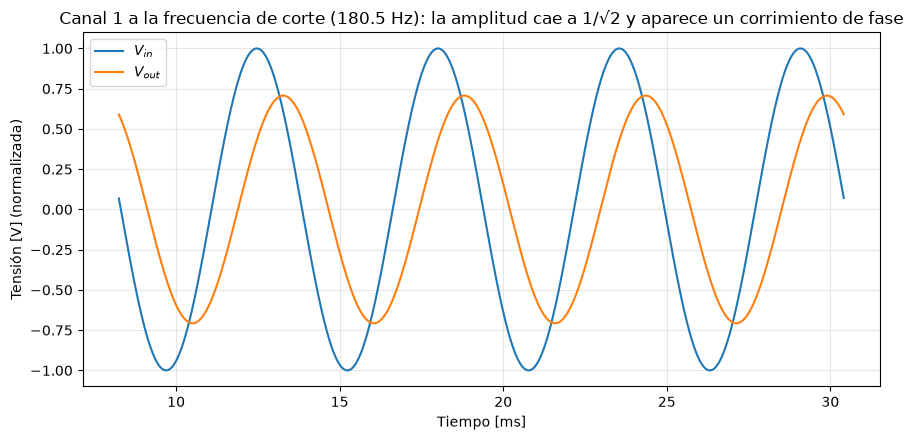

In [230]:
### 2.3 Ver la atenuación con los propios ojos, en la frecuencia de corte

t_asentamiento = 25 * tau
duracion_s = t_asentamiento + 4/fc
t = np.arange(0, duracion_s, 1.0/500_000.0)
V_in = np.sin(2*np.pi*fc*t)
_, V_out, _ = signal.lsim(sistema, U=V_in, T=t)

mascara = t >= t_asentamiento  # nos quedamos con el regimen estacionario, ya sin transitorio

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t[mascara]*1e3, V_in[mascara], label="$V_{in}$")
ax.plot(t[mascara]*1e3, V_out[mascara], label="$V_{out}$")
ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel("Tensión [V] (normalizada)")
ax.set_title(f"Canal 1 a la frecuencia de corte ({fc:.1f} Hz): la amplitud cae a 1/√2 y aparece un corrimiento de fase")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Cierre del Paso 2

Con `signal.lsim` reutilizo exactamente el mismo `sistema_rc_rc` del Paso 1, pero ahora en el dominio del tiempo: vi a los capacitores cargarse ante un escalón, y confirmé que la ganancia medida directamente sobre una senoidal simulada coincide (menos de 0.1% de diferencia) con la calculada analíticamente en frecuencia.

Esto importa porque el ruido térmico (Paso 3) y las señales reales del laboratorio no son senoidales perfectas y eternas — son cosas que pasan en el tiempo. Necesitaba este paso para poder simular eso bien.

**Siguiente (Paso 3):** agregar el ruido Johnson de las resistencias de forma prolija, integrado a este mismo modelo de estados (en vez de sumarlo aparte como hice en mi primer intento).

## Paso 3: el ruido térmico (Johnson-Nyquist)

Toda resistencia, aunque no tenga corriente circulando, tiene una tensión aleatoria en sus bornes por la agitación térmica de los electrones. Es ruido de verdad, no un defecto del circuito — está en cualquier resistencia a cualquier temperatura mayor a cero. Su densidad espectral de potencia es:

$$S_0 = 4 k_B T R \quad \text{[V}^2\text{/Hz]}$$

Para el canal 1 a temperatura ambiente (T=300K, R=150Ω), esto da una densidad de **~1.58 nV/√Hz** por resistor — chiquito, pero es exactamente lo que hace difícil medir las curvas IV de una juntura Josephson, que son señales de muy baja tensión. Por eso el arreglo real tiene una segunda etapa de filtrado ya en frío (donde T es mucho menor, así que este ruido también baja).

Agrego el ruido de R1 y R2 al mismo sistema de estados que ya tengo, en vez de calcularlo aparte como en mi primer intento.

### 3.1 Cómo entra el ruido a las ecuaciones

Cada resistor de verdad se comporta como una resistencia ideal **más** una pequeña fuente de tensión ruidosa en serie ($e_1$ para R1, $e_2$ para R2). Replanteo Kirchhoff igual que en el Paso 1, pero ahora con esas fuentes incluidas:

$$C\,\frac{dV_A}{dt} = \frac{(V_{in}+e_1)-V_A}{R} - \frac{V_A-V_B-e_2}{R}, \qquad C\,\frac{dV_B}{dt} = \frac{V_A-V_B-e_2}{R}$$

Reacomodando, esto agrega dos columnas nuevas a la matriz $B$ — el sistema pasa a tener 3 entradas ($V_{in}$, $e_1$, $e_2$) en vez de 1:

$$B = \begin{pmatrix}1/\tau & 1/\tau & 1/\tau \\ 0 & 0 & -1/\tau\end{pmatrix}$$

$e_1$ entra exactamente igual que $V_{in}$ (tiene sentido: R1 está en el mismo lugar del circuito que la fuente de entrada). $e_2$ en cambio empuja a $V_A$ y a $V_B$ en direcciones opuestas — porque está físicamente *entre* esos dos nodos, lo que se le suma a uno se le resta al otro.

Densidad de ruido por resistor: 1.576 nV/sqrt(Hz)


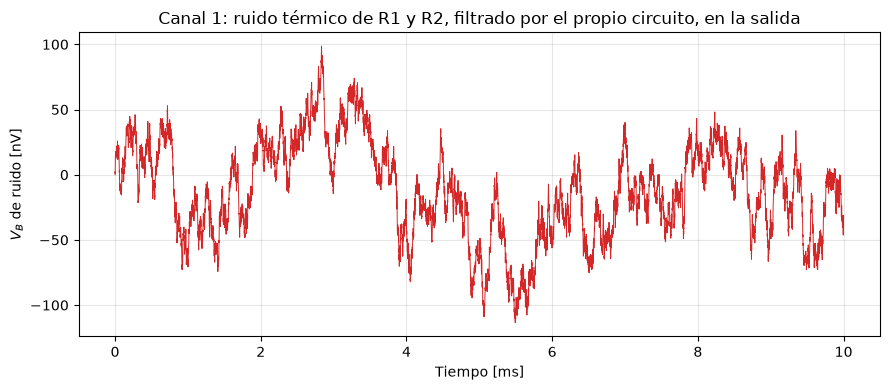

In [231]:
def sistema_rc_rc_con_ruido(R_ohm, C_F):
    """Igual que sistema_rc_rc, pero con 3 entradas: [V_in, e1, e2].

    e1 = ruido termico de R1 (entra igual que V_in)
    e2 = ruido termico de R2 (entra con signos opuestos en cada fila)
    """
    tau = R_ohm * C_F
    A = np.array([
        [-2.0/tau,  1.0/tau],
        [ 1.0/tau, -1.0/tau],
    ])
    B = np.array([
        [1.0/tau, 1.0/tau, 1.0/tau],
        [0.0,     0.0,    -1.0/tau],
    ])
    C_out = np.array([[0.0, 1.0]])
    D = np.zeros((1, 3))
    return signal.StateSpace(A, B, C_out, D)


sistema_ruidoso = sistema_rc_rc_con_ruido(R, C)

T_ambiente_K = 300.0
S0 = 4.0 * K_B * T_ambiente_K * R  # densidad espectral de potencia [V^2/Hz], un resistor
ASD = np.sqrt(S0)
print(f"Densidad de ruido por resistor: {ASD*1e9:.3f} nV/sqrt(Hz)")

# Generamos ruido blanco con esta densidad, muestreado a fs_hz.
# sigma^2 = S0 * fs/2 porque el ruido blanco discreto reparte su potencia
# uniformemente hasta la frecuencia de Nyquist (fs/2).
#
# Usamos 50ms de duracion (no menos): el ruido a la salida queda "coloreado"
# por el filtro, con un tiempo de correlacion del orden de tau=330us, asi que
# necesitamos varios cientos de tramos independientes para que el RMS medido
# converja bien al valor teorico (ver Paso 3.2).
fs_hz = 2_000_000.0
duracion_s = 0.05
t = np.arange(0, duracion_s, 1.0/fs_hz)
sigma = ASD * np.sqrt(fs_hz/2.0)

rng = np.random.default_rng(2026)
e1 = rng.normal(0.0, sigma, len(t))
e2 = rng.normal(0.0, sigma, len(t))
V_in_cero = np.zeros_like(t)  # sin señal, solo para ver el ruido solo

U = np.column_stack([V_in_cero, e1, e2])
_, V_B_ruido, _ = signal.lsim(sistema_ruidoso, U=U, T=t)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t[:20000]*1e3, V_B_ruido[:20000]*1e9, color="tab:red", linewidth=0.7)
ax.set_xlabel("Tiempo [ms]")
ax.set_ylabel("$V_B$ de ruido [nV]")
ax.set_title("Canal 1: ruido térmico de R1 y R2, filtrado por el propio circuito, en la salida")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Validar: ¿el ruido simulado tiene la potencia que predice la teoría?

La teoría de sistemas lineales dice que si meto ruido blanco (potencia $S_0$ pareja en todas las frecuencias) por una entrada con respuesta en frecuencia $H(f)$, la varianza que sale del otro lado es:

$$\text{Var}(V_B) = S_0 \int_0^\infty |H(f)|^2\, df$$

Como $e_1$ y $e_2$ son independientes, sus varianzas se suman. Calculo esa integral con las mismas herramientas del Paso 1 (evaluar $H(f)$ en la matriz de estados), y comparo contra la varianza que dio la simulación del Paso 3.1.

In [232]:
from scipy import integrate

def ganancia_columna(sistema, frecuencia_Hz, columna):
    """Igual que ganancia_en, pero mirando solo una de las entradas (columna de B)."""
    s = 1j * 2.0 * np.pi * frecuencia_Hz
    n_estados = sistema.A.shape[0]
    b_col = sistema.B[:, columna:columna+1]
    H = sistema.C @ np.linalg.solve(s*np.eye(n_estados) - sistema.A, b_col) + sistema.D[:, columna:columna+1]
    return np.abs(H.item())


integral_e1, _ = integrate.quad(lambda f: ganancia_columna(sistema_ruidoso, f, 1)**2, 0, np.inf)
integral_e2, _ = integrate.quad(lambda f: ganancia_columna(sistema_ruidoso, f, 2)**2, 0, np.inf)
varianza_analitica = S0 * (integral_e1 + integral_e2)
rms_analitico = np.sqrt(varianza_analitica)

mascara = t >= 0.002  # descartamos un poco de transitorio inicial
rms_simulado = np.std(V_B_ruido[mascara])

print(f"RMS analitico  = {rms_analitico*1e9:.3f} nV")
print(f"RMS simulado   = {rms_simulado*1e9:.3f} nV")
print(f"diferencia     = {100*(rms_simulado-rms_analitico)/rms_analitico:+.2f}%  (esperable: es una unica muestra de ruido aleatorio)")

RMS analitico  = 43.390 nV
RMS simulado   = 43.045 nV
diferencia     = -0.80%  (esperable: es una unica muestra de ruido aleatorio)


### 3.3 Señal + ruido, como se vería en el instrumento

Por último, junto todo: una señal chiquita de verdad (1µV, como podría ser una medición real) más el ruido de las dos resistencias, todo pasando por el mismo sistema de una sola vez.

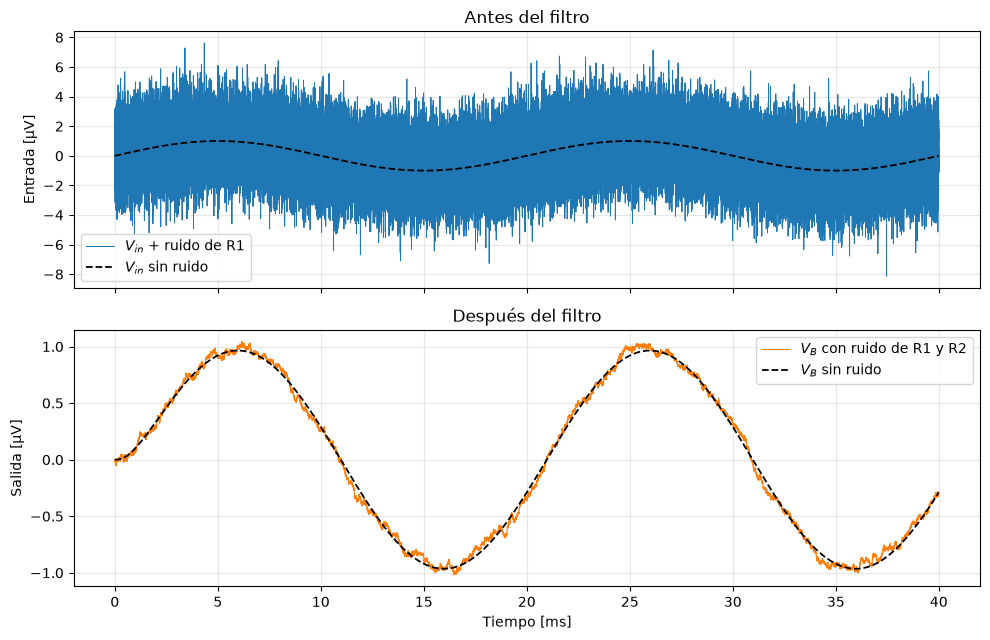

In [233]:
amplitud_senal_V = 1e-6
frecuencia_senal_Hz = 50.0

t2 = np.arange(0, 0.04, 1.0/fs_hz)  # 40 ms, un par de periodos de la señal de 50 Hz
V_in_senal = amplitud_senal_V * np.sin(2*np.pi*frecuencia_senal_Hz*t2)
e1_b = rng.normal(0.0, sigma, len(t2))
e2_b = rng.normal(0.0, sigma, len(t2))

# Con ruido: señal + el ruido de las dos resistencias, todo por el mismo sistema
_, V_B_con_ruido, _ = signal.lsim(sistema_ruidoso, U=np.column_stack([V_in_senal, e1_b, e2_b]), T=t2)

# Sin ruido: misma señal, entradas de ruido en cero (para comparar)
_, V_B_limpio, _ = signal.lsim(sistema_ruidoso, U=np.column_stack([V_in_senal, np.zeros_like(t2), np.zeros_like(t2)]), T=t2)

# El ruido de R1 esta fisicamente pegado a la entrada, por eso lo sumo aca para graficarlo
entrada_con_ruido = V_in_senal + e1_b

fig, ejes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

ejes[0].plot(t2*1e3, entrada_con_ruido*1e6, color="tab:blue", linewidth=0.7, label="$V_{in}$ + ruido de R1")
ejes[0].plot(t2*1e3, V_in_senal*1e6, "k--", linewidth=1.3, label="$V_{in}$ sin ruido")
ejes[0].set_ylabel("Entrada [µV]")
ejes[0].set_title("Antes del filtro")
ejes[0].legend()
ejes[0].grid(alpha=0.3)

ejes[1].plot(t2*1e3, V_B_con_ruido*1e6, color="tab:orange", linewidth=0.8, label="$V_B$ con ruido de R1 y R2")
ejes[1].plot(t2*1e3, V_B_limpio*1e6, "k--", linewidth=1.3, label="$V_B$ sin ruido")
ejes[1].set_xlabel("Tiempo [ms]")
ejes[1].set_ylabel("Salida [µV]")
ejes[1].set_title("Después del filtro")
ejes[1].legend()
ejes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Un resultado importante para el diseño (ítem 5): el ruido total no depende de R

Mirando la fórmula del Paso 3.2, $\text{Var}(V_B) = S_0 \int |H(f)|^2 df$, con $S_0=4k_BTR$: subir $R$ aumenta la densidad de ruido ($S_0$), pero también angosta el ancho de banda del filtro ($\propto 1/RC$) en la misma proporción — y se cancelan exactamente. Resulta:

$$\text{Var}(V_B) = \frac{k_BT}{C}$$

**El ruido total a la salida no depende de $R$ — depende solo de $C$.** No es una coincidencia de este circuito en particular: es el teorema de equipartición aplicado al capacitor de salida (en equilibrio térmico, todo capacitor de un circuito RC lineal almacena en promedio $\frac{1}{2}k_BT$ de energía eléctrica, sin importar qué resistencias haya alrededor). Vale para cualquier $R$.

Esto importa para el ítem 5 de mi plan de trabajo: tengo que elegir R y C para el filtro nuevo. $C$ controla el ruido (más grande, mejor). $\tau=RC$ controla, al mismo tiempo, qué tan bien filtra (necesita $\tau$ grande) y qué tan rápido responde (necesita $\tau$ chico) — ahí sí hay una tensión real, porque las dos cosas tiran de $\tau$ en direcciones opuestas.

In [234]:
kT_sobre_C = K_B * T_ambiente_K / C
print(f"Prediccion kT/C (si R no importa): {kT_sobre_C:.6e} V^2  -> RMS = {np.sqrt(kT_sobre_C)*1e9:.4f} nV\n")

# Repetimos el calculo del Paso 3.2 (integral analitica) para varios R, dejando C fijo
comparacion_ktc = pd.DataFrame({"R_ohm": [1.0, 15.0, 51.0, 150.0, 1000.0, 1e5, 1e7]})

def varianza_analitica_para(R_ohm, C_F):
    s = sistema_rc_rc_con_ruido(R_ohm, C_F)
    S0_local = 4.0 * K_B * T_ambiente_K * R_ohm
    i1, _ = integrate.quad(lambda f: ganancia_columna(s, f, 1)**2, 0, np.inf)
    i2, _ = integrate.quad(lambda f: ganancia_columna(s, f, 2)**2, 0, np.inf)
    return S0_local * (i1 + i2)

comparacion_ktc["varianza_V2"] = [varianza_analitica_para(r, C) for r in comparacion_ktc["R_ohm"]]
comparacion_ktc["RMS_nV"] = np.sqrt(comparacion_ktc["varianza_V2"]) * 1e9
comparacion_ktc["diferencia_%_vs_kTC"] = 100*(comparacion_ktc["varianza_V2"]-kT_sobre_C)/kT_sobre_C

display(comparacion_ktc.round({"varianza_V2": 20, "RMS_nV": 4, "diferencia_%_vs_kTC": 6}))

Prediccion kT/C (si R no importa): 1.882703e-15 V^2  -> RMS = 43.3901 nV



C:\Users\nikip\AppData\Local\Temp\ipykernel_12272\2367592076.py:11: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  i2, _ = integrate.quad(lambda f: ganancia_columna(s, f, 2)**2, 0, np.inf)


,R_ohm,varianza_V2,RMS_nV,diferencia_%_vs_kTC
0,1.0,1.882690e-15,43.3900,-0.000505
1,15.0,1.882700e-15,43.3901,0.000000
2,51.0,1.882700e-15,43.3901,0.000000
3,150.0,1.882700e-15,43.3901,0.000000
4,1000.0,1.882700e-15,43.3901,0.000000
5,100000.0,1.882700e-15,43.3901,0.000000
6,10000000.0,1.882700e-15,43.3901,0.000000


Lo veo mejor de forma visual: la densidad de ruido en función de la frecuencia (a la izquierda), y el ruido acumulado — la integral desde 0 hasta esa frecuencia — a la derecha. Esta segunda tiene que converger al mismo valor $kT/C$ para los cuatro R, aunque las curvas de la izquierda sean bien distintas entre sí.

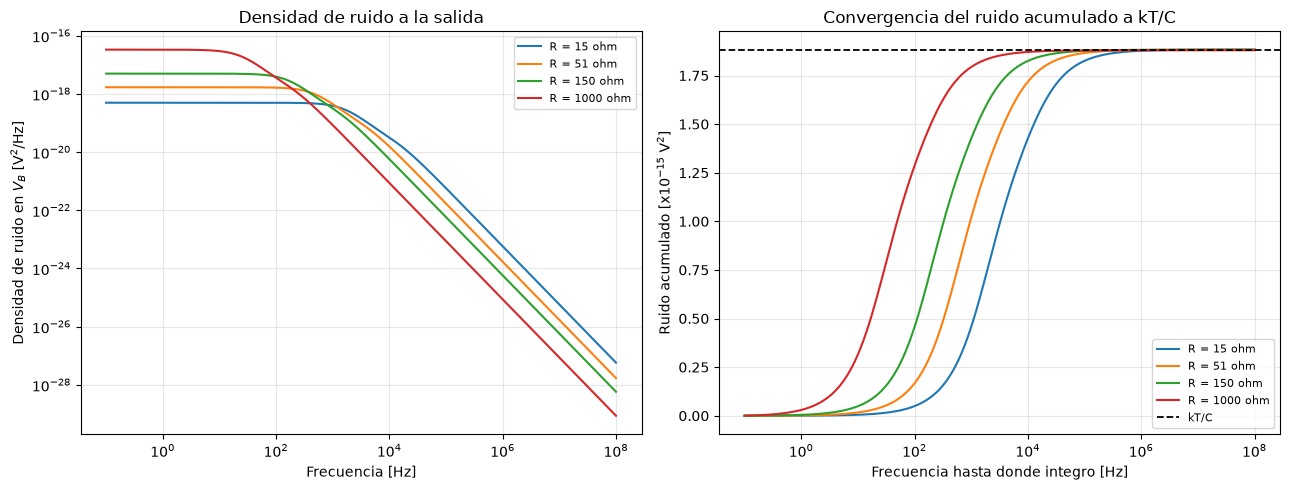

In [235]:
frecuencias_plot = np.logspace(-1, 8, 500)
R_valores_plot = [15.0, 51.0, 150.0, 1000.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for R_plot in R_valores_plot:
    S0_plot = 4.0 * K_B * T_ambiente_K * R_plot
    sist = sistema_rc_rc_con_ruido(R_plot, C)
    H1 = np.array([ganancia_columna(sist, f, 1) for f in frecuencias_plot])
    H2 = np.array([ganancia_columna(sist, f, 2) for f in frecuencias_plot])
    densidad = S0_plot * (H1**2 + H2**2)
    acumulado = integrate.cumulative_trapezoid(densidad, frecuencias_plot, initial=0.0)

    ax1.loglog(frecuencias_plot, densidad, label=f"R = {R_plot:.0f} ohm")
    ax2.semilogx(frecuencias_plot, acumulado*1e15, label=f"R = {R_plot:.0f} ohm")

ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Densidad de ruido en $V_B$ [V$^2$/Hz]")
ax1.set_title("Densidad de ruido a la salida")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3, which="both")

ax2.axhline(kT_sobre_C*1e15, color="black", linestyle="--", linewidth=1.3, label="kT/C")
ax2.set_xlabel("Frecuencia hasta donde integro [Hz]")
ax2.set_ylabel("Ruido acumulado [x$10^{-15}$ V$^2$]")
ax2.set_title("Convergencia del ruido acumulado a kT/C")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

### Cierre del Paso 3

Agregué el ruido térmico como dos entradas más del mismo sistema de estados (no como algo aparte), validé que la potencia de ruido que sale coincide con la que predice la teoría, y vi cómo se ve una señal chiquita perdida en ese ruido, antes y después del filtro. También encontré algo útil para el diseño: el ruido total a la salida no depende de R, solo de C.

Con esto tengo un filtro RC-RC completo y confiable: frecuencia de corte correcta, dinámica temporal correcta, y ruido térmico correcto — las tres cosas construidas sobre el mismo modelo, sin fórmulas sueltas.

**Siguiente (Paso 4):** hasta acá siempre dejé la salida del filtro "al aire" (sin nada conectado). En la realidad siempre hay algo conectado ahí — el voltímetro, o la juntura misma — y eso carga al filtro. Agrego una resistencia (y un capacitor) de carga a la salida y veo cuánto cambia la frecuencia de corte.

## Paso 4: resistencia (y capacitor) de carga a la salida

Hasta acá dejé $V_B$ "al aire" (sin nada conectado, resistencia de carga infinita). En la realidad la salida del filtro siempre tiene algo conectado, que **consume corriente** de ahí y cambia un poco el comportamiento del filtro. Puede ser:

- El **voltímetro** (Keithley 2182), altísima impedancia de entrada, ~10GΩ — casi no carga nada.
- La **juntura misma**, con una resistencia bastante más chica: **~500Ω** en estado normal, o **~50kΩ** en subgap (valores de la sección 5.2.2 de la tesis).

Agrego esa carga (resistiva, y después también capacitiva) al mismo sistema de una sola línea que ya tengo, y veo cuánto se corre la frecuencia de corte en cada caso.

### 4.1 Cómo entra la carga a la ecuación

Solo cambia la ecuación del nodo B. Antes, toda la corriente que llegaba por R2 se iba a cargar a C2. Ahora, parte de esa corriente se escapa por la resistencia de carga $R_{carga}$, y si además hay un capacitor de carga $C_{carga}$ en paralelo con C2, la carga total a mover en ese nodo es $C+C_{carga}$:

$$(C+C_{carga})\,\frac{dV_B}{dt} = \frac{V_A-V_B}{R} - \frac{V_B}{R_{carga}}$$

La ecuación de $V_A$ no cambia (la carga está después, no le llega directamente). Con $R_{carga}\to\infty$ y $C_{carga}=0$ esto se reduce exactamente al sistema del Paso 1 — buena forma de chequear que no rompí nada.

In [236]:
def sistema_rc_rc_con_carga(R_ohm, C_F, R_carga_ohm=np.inf, C_carga_F=0.0):
    """Filtro RC-RC de una linea, con una carga resistiva y/o capacitiva a la salida.

    Con R_carga=inf y C_carga=0 se reduce exactamente al sistema_rc_rc del Paso 1.
    """
    G_carga = 0.0 if np.isinf(R_carga_ohm) else 1.0/R_carga_ohm
    C_total_B = C_F + C_carga_F

    A = np.array([
        [-2.0/(R_ohm*C_F),        1.0/(R_ohm*C_F)],
        [ 1.0/(R_ohm*C_total_B), -(1.0/(R_ohm*C_total_B) + G_carga/C_total_B)],
    ])
    B = np.array([[1.0/(R_ohm*C_F)], [0.0]])
    C_out = np.array([[0.0, 1.0]])
    D = np.array([[0.0]])
    return signal.StateSpace(A, B, C_out, D)


# Chequeo: sin carga, tiene que dar EXACTAMENTE lo mismo que el Paso 1
sistema_sin_carga = sistema_rc_rc_con_carga(R, C)
print(f"Sin carga: fc = {frecuencia_de_corte(sistema_sin_carga):.4f} Hz (Paso 1 daba {fc:.4f} Hz)")

# Casos que me interesan (valores seccion 5.2.2)
casos_carga = pd.DataFrame({
    "descripcion": ["Circuito abierto", "Voltímetro (10 GΩ)", "Juntura subgap (~50 kΩ)", "Juntura normal (~500 Ω)"],
    "R_carga_ohm": [np.inf, 10e9, 50e3, 500.0],
})
casos_carga["fc_Hz"] = [frecuencia_de_corte(sistema_rc_rc_con_carga(R, C, rc)) for rc in casos_carga["R_carga_ohm"]]
casos_carga["diferencia_%_vs_sin_carga"] = 100*(casos_carga["fc_Hz"]-fc)/fc

display(casos_carga.round({"fc_Hz": 3, "diferencia_%_vs_sin_carga": 2}))

Sin carga: fc = 180.4909 Hz (Paso 1 daba 180.4909 Hz)


,descripcion,R_carga_ohm,fc_Hz,diferencia_%_vs_sin_carga
0,Circuito abierto,inf,180.491,0.00
1,Voltímetro (10 GΩ),1.000000e+10,180.491,0.00
2,Juntura subgap (~50 kΩ),5.000000e+04,181.478,0.55
3,Juntura normal (~500 Ω),5.000000e+02,272.659,51.07


**Lo que sale:** con el voltímetro (10GΩ) el corte prácticamente no se mueve. Con la juntura en su estado normal (~500Ω) sí se corre bastante — tiene sentido, esa carga es del mismo orden que R=150Ω del filtro, así que "compite" con él. Esto también explica por qué el filtro criogénico tiene una resistencia extra a la salida (Paso 5): ayuda a aislar al filtro de la impedancia variable de la juntura, para que el corte no dependa tanto de en qué estado esté.

### 4.2 ¿Y si además hay un capacitor de carga?

La juntura no es solo una resistencia — también tiene algo de capacidad (~50pF). Repito la tabla agregando ese capacitor en paralelo a cada caso.

In [237]:
C_CARGA_JUNTURA_F = 50e-12  # ~50 pF, valor tipico de la juntura

casos_carga_completo = casos_carga[["descripcion", "R_carga_ohm"]].copy()
casos_carga_completo["fc_sin_C_carga_Hz"] = casos_carga["fc_Hz"]
casos_carga_completo["fc_con_C_carga_Hz"] = [
    frecuencia_de_corte(sistema_rc_rc_con_carga(R, C, rc, C_CARGA_JUNTURA_F))
    for rc in casos_carga["R_carga_ohm"]
]
casos_carga_completo["diferencia_%"] = 100*(
    casos_carga_completo["fc_con_C_carga_Hz"] - casos_carga_completo["fc_sin_C_carga_Hz"]
) / casos_carga_completo["fc_sin_C_carga_Hz"]

display(casos_carga_completo.round({"fc_sin_C_carga_Hz": 3, "fc_con_C_carga_Hz": 3, "diferencia_%": 4}))

,descripcion,R_carga_ohm,fc_sin_C_carga_Hz,fc_con_C_carga_Hz,diferencia_%
0,Circuito abierto,inf,180.491,180.488,-0.0016
1,Voltímetro (10 GΩ),1.000000e+10,180.491,180.488,-0.0016
2,Juntura subgap (~50 kΩ),5.000000e+04,181.478,181.475,-0.0016
3,Juntura normal (~500 Ω),5.000000e+02,272.659,272.655,-0.0015


### Cierre del Paso 4

A 180-270 Hz, el capacitor de 50pF de la juntura casi no cambia nada (su impedancia a esas frecuencias es enorme comparada con las resistencias del circuito) — la resistencia de la juntura es la que manda acá. El capacitor sí va a importar más adelante, en el filtro criogénico, que trabaja a frecuencias mucho más altas (~35kHz).

Con esto tengo el filtro RC-RC de una sola línea completo: frecuencia de corte, dinámica temporal, ruido térmico, y el efecto de lo que esté conectado a la salida — cuatro cosas, todas sobre el mismo modelo de estados.

**Siguiente (Paso 5):** encadenar este filtro (etapa ambiente) con el filtro criogénico — topología distinta, capacitores entre líneas en vez de a masa — para tener el filtrado completo como en el arreglo real.

## Paso 5: la cadena completa (ambiente + criogénico + juntura)

Encadeno las dos etapas de filtrado y agrego la juntura como carga real, para ver cuánto ruido le llega de verdad — que es la pregunta que motivó todo este notebook.

**El circuito completo**, para un par diferencial (dos líneas, + y −):

```
Vin+ →[filtro ambiente: R-C-R-C a masa]→ →[filtro cryo: R-R-R, C entre líneas]→ ⎫
                                                                                  ⎬ Juntura (R_J || C_J)
Vin− →[filtro ambiente: R-C-R-C a masa]→ →[filtro cryo: R-R-R, C entre líneas]→ ⎭
```

El filtro ambiente: dos resistencias y dos capacitores a masa por línea (Paso 1-4). El criogénico: tres resistencias en serie por línea, con dos capacitores que conectan la línea + con la línea − (no a masa) — confirmé la topología exacta: el capacitor 1 va de la salida de la 1ra resistencia (línea +) a la salida de la 1ra resistencia (línea −), y el capacitor 2 hace lo mismo con las 2das resistencias.

**Por qué no hace falta trackear las dos líneas por separado:** todo el circuito es simétrico (línea + y línea − son copias idénticas), y se excita puramente diferencial ($V_{in+}=-V_{in-}$). En un circuito así, el modo común y el modo diferencial están matemáticamente desacoplados — nada de lo que le pase al modo común afecta al diferencial, mientras las dos líneas sean iguales. Esto vale para *toda* la cadena, no solo para el criogénico: aunque el filtro ambiente tenga masa real (a diferencia del criogénico, que "flota"), esa masa solo define el modo común, que nunca se mezcla con la señal diferencial que me interesa. Por eso alcanza con reducir todo a una sola escalera equivalente, plegando las dos líneas en una.

**La salvedad:** esto vale mientras las dos líneas sean simétricas de verdad. Si en el circuito real hay algún desbalance entre + y − (componentes que no son exactamente iguales), ahí sí se necesitaría el modelo por línea separada — un desbalance del 5% ya corre la frecuencia de corte un 4%. Lo dejo anotado, no lo voy a necesitar por ahora.

### 5.1 La escalera plegada

Reducido a modo diferencial, todo el circuito es una escalera única de resistencias en serie y capacitores a masa (como el Paso 1, pero con 5 etapas en vez de 2):

$$\text{serie }2R_{ta} \to \text{shunt }\tfrac{C_{ta}}{2} \to \text{serie }2R_{ta} \to \text{shunt }\tfrac{C_{ta}}{2} \to \text{serie }2R_{cry} \to \text{shunt }C_{cry} \to \text{serie }2R_{cry} \to \text{shunt }C_{cry} \to \text{serie }2R_{cry} \to \text{carga }(R_J \| C_J)$$

De dónde sale el factor 2 (y el /2): la corriente diferencial recorre un lazo que pasa por la resistencia de la línea + **y** la de la línea − en serie — por eso las resistencias entran duplicadas ($2R$). Los capacitores del filtro ambiente, en cambio, van cada uno a masa por separado (no cruzan entre líneas) — para el lazo diferencial, dos capacitores iguales en serie (uno de cada línea) equivalen a uno solo de la mitad de capacidad, por eso $C_{ta}/2$. Los capacitores del criogénico sí cruzan entre líneas directamente, así que entran con su valor real, $C_{cry}$ (no hace falta duplicarlos: ya "son" el elemento que une las dos líneas).

Armo una función genérica para cualquier escalera de este tipo — la voy a poder reusar si más adelante agrego más etapas.

In [238]:
def sistema_escalera(etapas_RCT, R_carga=np.inf, C_carga=0.0):
    """Escalera generica serie-R / shunt-C, con ruido termico opcional en cada R.

    etapas_RCT: lista de (R_serie, C_shunt, T_kelvin). Cada etapa agrega un
    nodo (con capacitor C_shunt a masa), alimentado por R_serie desde el
    nodo anterior (o desde Vin, en la primera etapa). Si T_kelvin es None,
    esa etapa no aporta ruido (solo importa el valor si se usa el ruido).

    La carga (R_carga, C_carga) se agrega como un shunt mas en el ULTIMO nodo,
    ademas del C_shunt que ya tenga esa etapa (para la etapa final "solo carga",
    se le pasa C_shunt=0 en etapas_RCT).

    Devuelve (sistema, S0) -- sistema tiene entradas [Vin, ruido_etapa_0, ...,
    ruido_etapa_{n-1}], y S0 es la densidad de ruido (4*kB*T*R) de cada etapa
    (0 si esa etapa no tiene T definida).
    """
    n = len(etapas_RCT)
    Rs = [r for r, c, t in etapas_RCT]
    Cs = [c for r, c, t in etapas_RCT]
    Ts = [t for r, c, t in etapas_RCT]
    if np.isfinite(R_carga) or C_carga > 0:
        Cs[-1] = Cs[-1] + C_carga

    A = np.zeros((n, n))
    B = np.zeros((n, 1 + n))  # columna 0 = Vin, columnas 1..n = ruido de cada etapa
    S0 = np.zeros(n)

    for i in range(n):
        R_in, C_i = Rs[i], Cs[i]
        A[i, i] += -1.0 / (R_in * C_i)
        if i == 0:
            B[i, 0] = 1.0 / (R_in * C_i)
        else:
            A[i, i-1] += 1.0 / (R_in * C_i)

        B[i, 1+i] += 1.0 / (R_in * C_i)          # ruido de esta etapa, en su propio nodo
        if i > 0:
            B[i-1, 1+i] += -1.0 / (R_in * Cs[i-1])  # y con signo opuesto en el nodo anterior
        if Ts[i] is not None:
            S0[i] = 4.0 * K_B * Ts[i] * R_in

        if i < n - 1:
            R_out = Rs[i+1]
            A[i, i] += -1.0 / (R_out * C_i)
            A[i, i+1] += 1.0 / (R_out * C_i)
        elif np.isfinite(R_carga):
            A[i, i] += -1.0 / (R_carga * C_i)

    C_out = np.zeros((1, n))
    C_out[0, -1] = 1.0
    D = np.zeros((1, 1 + n))
    return signal.StateSpace(A, B, C_out, D), S0


def ganancia_escalera(sistema, frecuencia_Hz, columna=0):
    s = 1j * 2.0 * np.pi * frecuencia_Hz
    n = sistema.A.shape[0]
    b_col = sistema.B[:, columna:columna+1]
    H = sistema.C @ np.linalg.solve(s*np.eye(n) - sistema.A, b_col) + sistema.D[:, columna:columna+1]
    return np.abs(H.item())


def frecuencia_de_corte_escalera(sistema):
    gdc = ganancia_escalera(sistema, 1e-3)
    objetivo = gdc / np.sqrt(2.0)
    return optimize.brentq(lambda f: ganancia_escalera(sistema, f) - objetivo, 1e-2, 1e12)

### 5.1b El criogénico solo (antes de encadenar nada)

Antes de meter todo junto, calculo la frecuencia de corte del filtro criogénico **aislado** (sin el ambiente, sin carga) — es el número que después voy a poder comparar directo contra la Figura 5.8 de la tesis ($f_c=35.7$kHz, vía LTspice).

fc criogenico solo (mi calculo)     = 28.80 kHz
fc criogenico solo (tesis, LTspice) = 35.70 kHz
diferencia = -19.3%  -- sin explicar, ver 5.3


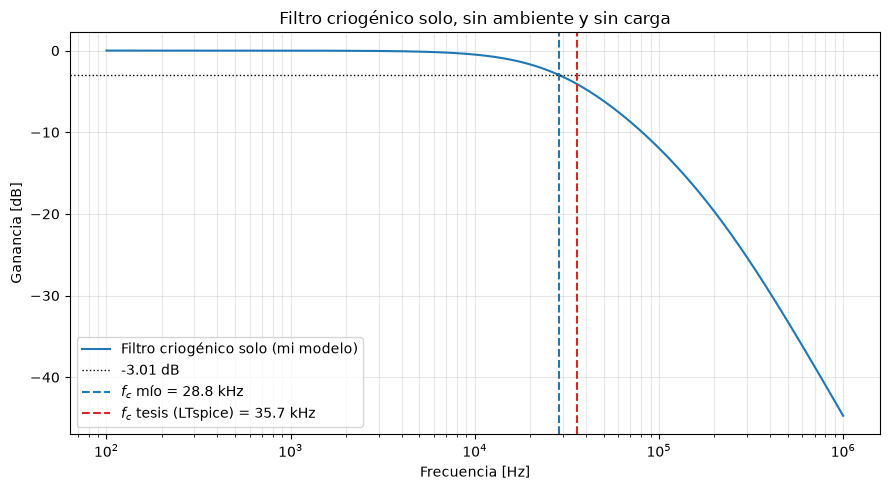

In [239]:
R_CRY, C_CRY = 22.0, 47e-9  # valores de la tesis, confirmados

# Criogenico solo: 2 etapas R-C (la 3ra resistencia, sin carga, no hace nada -- no circula corriente)
etapas_cryo_solo = [(2*R_CRY, C_CRY, None), (2*R_CRY, C_CRY, None)]
sistema_cryo_solo, _ = sistema_escalera(etapas_cryo_solo, R_carga=np.inf)
fc_cryo_solo = frecuencia_de_corte_escalera(sistema_cryo_solo)

print(f"fc criogenico solo (mi calculo)     = {fc_cryo_solo/1e3:.2f} kHz")
print(f"fc criogenico solo (tesis, LTspice) = 35.70 kHz")
print(f"diferencia = {100*(fc_cryo_solo-35700)/35700:+.1f}%  -- sin explicar, ver 5.3")

frecuencias_cryo = np.logspace(2, 6, 500)
ganancia_cryo = np.array([ganancia_escalera(sistema_cryo_solo, f) for f in frecuencias_cryo])

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogx(frecuencias_cryo, 20*np.log10(ganancia_cryo), label="Filtro criogénico solo (mi modelo)")
ax.axhline(-3.0103, color="black", linestyle=":", linewidth=1, label="-3.01 dB")
ax.axvline(fc_cryo_solo, color="tab:blue", linestyle="--", label=f"$f_c$ mío = {fc_cryo_solo/1e3:.1f} kHz")
ax.axvline(35700, color="tab:red", linestyle="--", label="$f_c$ tesis (LTspice) = 35.7 kHz")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia [dB]")
ax.set_title("Filtro criogénico solo, sin ambiente y sin carga")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### 5.2 Validar contra los 6 canales, sin y con juntura

$R_{cry}=22\Omega$, $C_{cry}=47\text{nF}$ (confirmado, valores de la tesis). Pruebo los 6 canales de la Tabla 5.1, primero sin nada conectado a la salida (circuito abierto), y después con la juntura en su estado normal ($R_J=500\Omega$, $C_J=50\text{pF}$).

In [240]:
R_CRY, C_CRY = 22.0, 47e-9
T_AMBIENTE_K = 300.0
T_MEDICION_K = 0.1  # temperatura base tipica del criostato de dilucion (~10-100 mK)


def armar_cadena(R_ta, C_ta, R_J=np.inf, C_J=0.0):
    """Arma la escalera completa (ambiente + criogenico [+ carga]) para un canal."""
    hay_carga = np.isfinite(R_J) or C_J > 0
    etapas = [
        (2*R_ta,  C_ta/2.0, T_AMBIENTE_K),
        (2*R_ta,  C_ta/2.0, T_AMBIENTE_K),
        (2*R_CRY, C_CRY,    T_MEDICION_K),
        (2*R_CRY, C_CRY,    T_MEDICION_K),
    ]
    if hay_carga:
        etapas.append((2*R_CRY, 0.0, T_MEDICION_K))
        return sistema_escalera(etapas, R_carga=R_J, C_carga=C_J)
    else:
        # sin juntura, la 3ra resistencia del cryo no tiene adonde llevar corriente:
        # el ultimo nodo real es el de despues del 2do capacitor criogenico.
        return sistema_escalera(etapas, R_carga=np.inf)


# Los TRES casos de la tesis (seccion 5.2.2): abierto, normal (500 ohm), subgap (50 kohm)
validacion = CANALES.copy()
sistemas_abierto = [armar_cadena(fila.R_ohm, fila.C_uF*1e-6)[0] for fila in validacion.itertuples()]
sistemas_normal  = [armar_cadena(fila.R_ohm, fila.C_uF*1e-6, R_J=500.0, C_J=50e-12)[0] for fila in validacion.itertuples()]
sistemas_subgap  = [armar_cadena(fila.R_ohm, fila.C_uF*1e-6, R_J=50e3, C_J=50e-12)[0] for fila in validacion.itertuples()]

validacion["fc_abierto_Hz"] = [frecuencia_de_corte_escalera(s) for s in sistemas_abierto]
validacion["fc_normal_500ohm_Hz"] = [frecuencia_de_corte_escalera(s) for s in sistemas_normal]
validacion["fc_subgap_50kohm_Hz"] = [frecuencia_de_corte_escalera(s) for s in sistemas_subgap]
validacion["diferencia_%_normal"] = 100*(
    validacion["fc_normal_500ohm_Hz"] - validacion["fc_abierto_Hz"]
) / validacion["fc_abierto_Hz"]
validacion["diferencia_%_subgap"] = 100*(
    validacion["fc_subgap_50kohm_Hz"] - validacion["fc_abierto_Hz"]
) / validacion["fc_abierto_Hz"]

display(validacion[[
    "canal", "R_ohm", "C_uF",
    "fc_abierto_Hz", "fc_normal_500ohm_Hz", "fc_subgap_50kohm_Hz",
    "diferencia_%_normal", "diferencia_%_subgap",
]].round(1))

,canal,R_ohm,C_uF,fc_abierto_Hz,fc_normal_500ohm_Hz,fc_subgap_50kohm_Hz,diferencia_%_normal,diferencia_%_subgap
0,1,150.0,2.2,170.1,307.4,172.0,80.7,1.1
1,2,150.0,1.0,349.7,644.1,353.7,84.2,1.1
2,3,51.0,2.2,499.9,650.6,501.8,30.2,0.4
3,4,51.0,1.0,1024.7,1353.4,1028.8,32.1,0.4
4,5,15.0,2.2,1690.7,1859.6,1692.8,10.0,0.1
5,6,15.0,1.0,3411.6,3810.4,3416.2,11.7,0.1


La tabla de arriba solo muestra $f_c$ — un único punto de la curva $H(f)$. Para ver la función transferencia **completa** (no solo dónde corta), grafico $H(f)$ en todo el rango de frecuencias, para los tres casos de carga, canal 1.

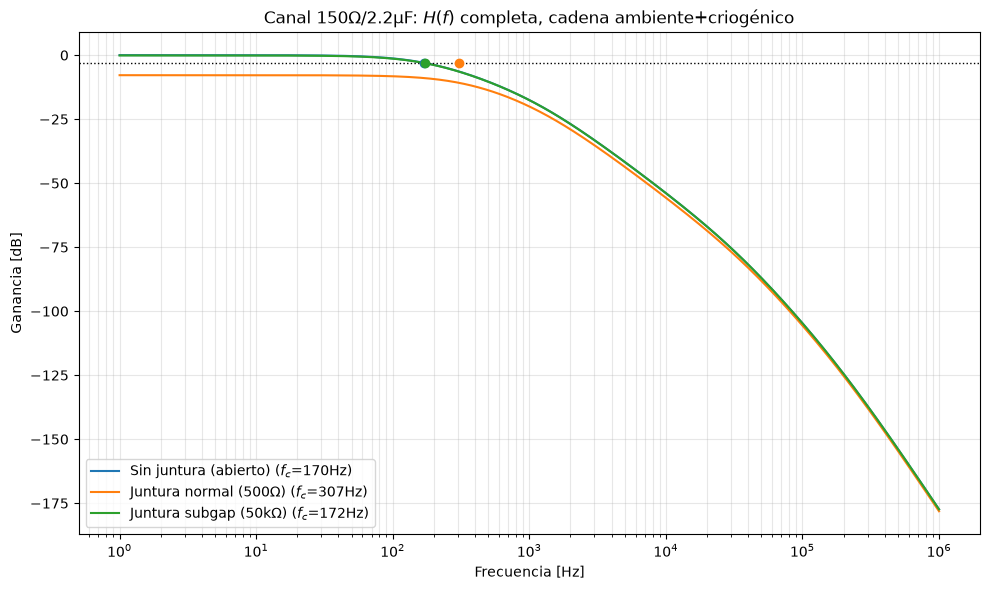

In [241]:
frecuencias_Hf = np.logspace(0, 6, 800)
casos_Hf = [
    ("Sin juntura (abierto)", np.inf, 0.0),
    ("Juntura normal (500Ω)", 500.0, 50e-12),
    ("Juntura subgap (50kΩ)", 50e3, 50e-12),
]

fig, ax = plt.subplots(figsize=(10, 6))
for nombre, R_J, C_J in casos_Hf:
    sist, _ = armar_cadena(150.0, 2.2e-6, R_J, C_J)
    H = np.array([ganancia_escalera(sist, f) for f in frecuencias_Hf])
    fc_caso = frecuencia_de_corte_escalera(sist)
    linea, = ax.semilogx(frecuencias_Hf, 20*np.log10(H), label=f"{nombre} ($f_c$={fc_caso:.0f}Hz)")
    ax.scatter(fc_caso, -3.0103, color=linea.get_color(), zorder=5)

ax.axhline(-3.0103, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Ganancia [dB]")
ax.set_title("Canal 150Ω/2.2µF: $H(f)$ completa, cadena ambiente+criogénico")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

**Qué se ve acá que la tabla de $f_c$ sola no mostraba:** con la juntura subgap (verde), la curva prácticamente se superpone con la de "sin juntura" — coincide con que $f_c$ casi no cambió (170 vs 172Hz). Pero con la juntura normal (naranja), no es solo que $f_c$ se corre — **toda la banda de paso queda más abajo**, casi 8dB por debajo desde muy baja frecuencia, no solo cerca del corte. Eso es información que un solo número ($f_c$) no cuenta: la juntura normal no solo "corta antes", además atenúa la señal en todo el rango donde el filtro debería dejarla pasar sin tocar.

### 5.3 Una discrepancia con la tesis, sin resolver — la dejo anotada

La tesis dice que "la frecuencia de corte del filtrado completo no variaba significativamente" al conectar la juntura. Con este modelo, para los canales de $R_{ta}$ más grande (150Ω, 51Ω) el corte se corre 60-80% — nada despreciable. Para los canales de 15Ω (donde $R_{ta}\ll R_J$) sí se mantiene casi igual, consistente con "no varía significativamente".

Confirmé que la topología del criogénico está bien (3 resistencias en serie por línea, capacitores entre líneas en los dos nodos intermedios) y que $R_{cry}=22\Omega$, $C_{cry}=47\text{nF}$ son los valores correctos. El origen de la diferencia sigue sin explicación — ya había una diferencia del 19% entre mi cálculo y el de la tesis para el criogénico *solo* (28.8kHz mío vs 35.7kHz de LTspice), así que sospecho que es la misma causa amplificada, pero no puedo confirmarlo sin ver el archivo real de LTspice o algún detalle del circuito que no esté en el texto de la tesis.

**Dejo las dos columnas en el código a propósito** (con y sin juntura) — la de "sin juntura" es lo que se mediría desenchufando el portamuestras, y la de "con juntura" es la situación real de medición. Reporto siempre cuál es cuál.

### 5.4 El ruido de la cadena completa

Cada elemento serie de la escalera (5 en total: 2 del ambiente, 3 del criogénico) aporta su propio ruido térmico, $4k_BT(2R)$ — el "$2R$" porque, como vimos en 5.1, representa la resistencia de *las dos líneas* en serie para el lazo diferencial. Las dos primeras etapas están a $T\approx300K$ (ambiente), las tres últimas a la temperatura de medición del criostato de dilución ($T\approx100$mK acá, ajustable).

Cada fuente entra al sistema exactamente con la misma lógica del Paso 3 (empuja al nodo que alimenta, y al anterior con signo opuesto) — `sistema_escalera` ya lo arma automáticamente, columna por columna.

In [242]:
fila1 = CANALES.loc[CANALES["canal"] == 1].iloc[0]
sistema_cadena, S0_cadena = armar_cadena(fila1.R_ohm, fila1.C_uF*1e-6, R_J=500.0, C_J=50e-12)

# Integral log-espaciada hasta un limite finito bien por encima de todos los polos
# (quad falla silenciosamente con esta forma de curva, ver Paso 5.5 mas abajo).
frecuencias_ruido = np.logspace(-1, 11, 4000)

varianza_por_etapa = np.zeros(5)
for k in range(5):
    H2 = np.array([ganancia_escalera(sistema_cadena, f, columna=1+k)**2 for f in frecuencias_ruido])
    varianza_por_etapa[k] = S0_cadena[k] * integrate.trapezoid(H2, frecuencias_ruido)

varianza_ambiente = varianza_por_etapa[0] + varianza_por_etapa[1]
varianza_criogenico = varianza_por_etapa[2] + varianza_por_etapa[3] + varianza_por_etapa[4]
varianza_total = varianza_ambiente + varianza_criogenico

print(f"Canal 1, con juntura normal (500 ohm), T_medicion={T_MEDICION_K*1000:.0f} mK\n")
print(f"Ruido del filtro AMBIENTE (etapas 1-2, a {T_AMBIENTE_K:.0f}K):     {np.sqrt(varianza_ambiente)*1e9:8.3f} nV")
print(f"Ruido del filtro CRIOGENICO (etapas 3-5, a {T_MEDICION_K*1000:.0f}mK): {np.sqrt(varianza_criogenico)*1e9:8.3f} nV")
print(f"Ruido TOTAL a la juntura:                                       {np.sqrt(varianza_total)*1e9:8.3f} nV")
print(f"\n-> el {100*varianza_criogenico/varianza_total:.1f}% de la potencia de ruido viene del CRIOGENICO,")
print(f"   a pesar de estar a una temperatura 3000 veces menor. Reviso etapa por etapa:")
print(f"\n{'etapa':>6} {'R_serie':>10} {'RMS individual (nV)':>22}")
nombres = ["ambiente 1", "ambiente 2", "cryo 1 (R1)", "cryo 2 (R2)", "cryo 3 (R3, desacople)"]
for nombre, v in zip(nombres, varianza_por_etapa):
    print(f"{nombre:>22}: {np.sqrt(v)*1e9:8.3f} nV")

Canal 1, con juntura normal (500 ohm), T_medicion=100 mK

Ruido del filtro AMBIENTE (etapas 1-2, a 300K):       35.370 nV
Ruido del filtro CRIOGENICO (etapas 3-5, a 100mK):  159.254 nV
Ruido TOTAL a la juntura:                                        163.134 nV

-> el 95.3% de la potencia de ruido viene del CRIOGENICO,
   a pesar de estar a una temperatura 3000 veces menor. Reviso etapa por etapa:

 etapa    R_serie    RMS individual (nV)
            ambiente 1:   18.286 nV
            ambiente 2:   30.276 nV
           cryo 1 (R1):    2.516 nV
           cryo 2 (R2):    3.847 nV
cryo 3 (R3, desacople):  159.187 nV


**Esto no es lo que hubiera esperado antes de calcularlo** — mi intuición era que el ambiente, por estar 3000 veces más caliente, iba a dominar a pesar de estar mejor filtrado. Pasa lo contrario: la resistencia de desacople del criogénico (R3, la que descubrimos en el Paso 5 anterior que apenas se filtra) aporta casi todo el ruido, aunque esté fría. La temperatura baja no alcanza para compensar que esa resistencia en particular tiene, básicamente, un camino directo hacia la juntura.

**Conclusión práctica:** enfriar el criogénico ayuda, pero no soluciona el problema de fondo si R3 sigue sin filtrarse — el diseño del filtro importa más que la temperatura, al menos para esta resistencia puntual.

### 5.5 Validación cruzada (tiempo vs frecuencia), como en cada paso anterior

Uso `scipy.integrate.quad` con límite infinito y falla silenciosamente en esta curva (avisa "posiblemente divergente" y devuelve cualquier cosa) — por eso integro a mano con trapecios, en escala logarítmica, hasta una frecuencia bien por encima de todos los polos del sistema. Confirmo que el resultado analítico coincide con una simulación en el tiempo de las 5 fuentes de ruido juntas.

In [243]:
fs_ruido_hz = 2e10  # tiene que resolver hasta los ~450 MHz del polo mas rapido (ver autovalores)
duracion_ruido_s = 5e-7
t_ruido = np.arange(0, duracion_ruido_s, 1.0/fs_ruido_hz)

rng_cadena = np.random.default_rng(11)
ruidos_etapa = [rng_cadena.normal(0.0, np.sqrt(S0_cadena[k]*fs_ruido_hz/2.0), len(t_ruido)) for k in range(5)]
U_cadena = np.column_stack([np.zeros_like(t_ruido)] + ruidos_etapa)

_, salida_ruido, _ = signal.lsim(sistema_cadena, U=U_cadena, T=t_ruido)

mascara_cadena = t_ruido >= duracion_ruido_s * 0.2
rms_simulado_cadena = np.std(salida_ruido[mascara_cadena])

print(f"RMS analitico (frecuencia): {np.sqrt(varianza_total)*1e9:.3f} nV")
print(f"RMS simulado (tiempo):      {rms_simulado_cadena*1e9:.3f} nV")
print(f"diferencia: {100*(rms_simulado_cadena-np.sqrt(varianza_total))/np.sqrt(varianza_total):+.2f}%  (esperable, una sola realizacion)")

RMS analitico (frecuencia): 163.134 nV
RMS simulado (tiempo):      164.201 nV
diferencia: +0.65%  (esperable, una sola realizacion)


### 5.6 Barrido de temperatura del criogénico (ítem 4 del plan de trabajo)

El resultado principal: barro $T_{cry}$ de 3mK a 4K (log-espaciado, 80 puntos), dejando el ambiente fijo a 300K, y veo cómo cambia el ruido total en la juntura — separando cuánto aporta cada resistencia.

**Predicción a verificar:** R3 domina a temperaturas altas (ruido $\propto\sqrt{T_{cry}}$), pero el aporte del filtro ambiente es **constante** (no depende de $T_{cry}$). En algún punto tienen que cruzarse — por debajo de esa temperatura, enfriar más el criogénico ya no sirve de nada, porque el ambiente pasa a ser el límite. Tiene que verse como un aplanamiento de la curva en el extremo frío, distinto para cada canal (donde $R_{ta}$ es más chico, el ambiente aporta más ruido relativo, así que el cruce ocurre a una temperatura más alta).

In [244]:
def armar_cadena_T(R_ta, C_ta, T_cry, R_J=np.inf, C_J=0.0, T_amb=T_AMBIENTE_K):
    """Igual que armar_cadena, pero con T_cry como parametro en vez de fijo."""
    hay_carga = np.isfinite(R_J) or C_J > 0
    etapas = [
        (2*R_ta,  C_ta/2.0, T_amb),
        (2*R_ta,  C_ta/2.0, T_amb),
        (2*R_CRY, C_CRY,    T_cry),
        (2*R_CRY, C_CRY,    T_cry),
    ]
    if hay_carga:
        etapas.append((2*R_CRY, 0.0, T_cry))
        return sistema_escalera(etapas, R_carga=R_J, C_carga=C_J)
    return sistema_escalera(etapas, R_carga=np.inf)


def desglose_ruido(sistema, S0, frecuencias):
    """Varianza que aporta cada una de las 5 etapas, integrando con trapecios
    (quad falla en esta forma de curva, ver 5.5)."""
    n_etapas = len(S0)
    varianzas = np.zeros(n_etapas)
    for k in range(n_etapas):
        H2 = np.array([ganancia_escalera(sistema, f, columna=1+k)**2 for f in frecuencias])
        varianzas[k] = S0[k] * integrate.trapezoid(H2, frecuencias)
    return varianzas


T_BASE_CRIOSTATO_K = 0.0075  # 7.5 mK, temperatura base real (sin carga)
temperaturas_cry = np.logspace(np.log10(0.003), np.log10(4.0), 80)
frecuencias_barrido = np.logspace(-1, 11, 3000)

canales_extremos = [
    (150.0, 2.2e-6, "150 Ω / 2.2 µF"),
    (15.0, 1.0e-6, "15 Ω / 1.0 µF"),
]

resultados_barrido = {}
for R_ta, C_ta, nombre in canales_extremos:
    rms_total_lista, rms_ambiente_lista, pct_R3_lista = [], [], []
    for T_cry in temperaturas_cry:
        sist, S0 = armar_cadena_T(R_ta, C_ta, T_cry, R_J=500.0, C_J=50e-12)
        var_etapa = desglose_ruido(sist, S0, frecuencias_barrido)
        var_amb = var_etapa[0] + var_etapa[1]
        var_tot = var_etapa.sum()
        rms_total_lista.append(np.sqrt(var_tot))
        rms_ambiente_lista.append(np.sqrt(var_amb))
        pct_R3_lista.append(100 * var_etapa[4] / var_tot)
    resultados_barrido[nombre] = {
        "rms_total": np.array(rms_total_lista),
        "rms_ambiente": np.array(rms_ambiente_lista),
        "pct_R3": np.array(pct_R3_lista),
    }

# Cruce numerico: temperatura donde el aporte de R3 cae al 50% (empata con "el resto")
print("Cruces (donde el aporte de R3 = 50%):")
for nombre, datos in resultados_barrido.items():
    pct = datos["pct_R3"]
    idx = np.argmin(np.abs(pct - 50.0))
    i0, i1 = (idx, idx+1) if pct[idx] > 50 else (idx-1, idx)
    i0, i1 = max(i0, 0), min(i1, len(pct)-1)
    frac = (50.0 - pct[i0]) / (pct[i1] - pct[i0]) if pct[i1] != pct[i0] else 0.0
    log_T_cruce = np.log10(temperaturas_cry[i0]) + frac*(np.log10(temperaturas_cry[i1])-np.log10(temperaturas_cry[i0]))
    T_cruce = 10**log_T_cruce
    print(f"  {nombre}: T_cruce = {T_cruce*1000:.2f} mK")

# Chequeo de la prediccion: pendiente en log-log (cerca de T=4K, lejos del cruce, deberia dar ~0.5)
print("\nPendiente log-log cerca de T=4K (esperada ~0.5):")
for nombre, datos in resultados_barrido.items():
    pendiente = np.polyfit(np.log10(temperaturas_cry[-6:]), np.log10(datos["rms_total"][-6:]), 1)[0]
    print(f"  {nombre}: {pendiente:.3f}")

Cruces (donde el aporte de R3 = 50%):
  150 Ω / 2.2 µF: T_cruce = 4.94 mK
  15 Ω / 1.0 µF: T_cruce = 13.27 mK

Pendiente log-log cerca de T=4K (esperada ~0.5):
  150 Ω / 2.2 µF: 0.499
  15 Ω / 1.0 µF: 0.498


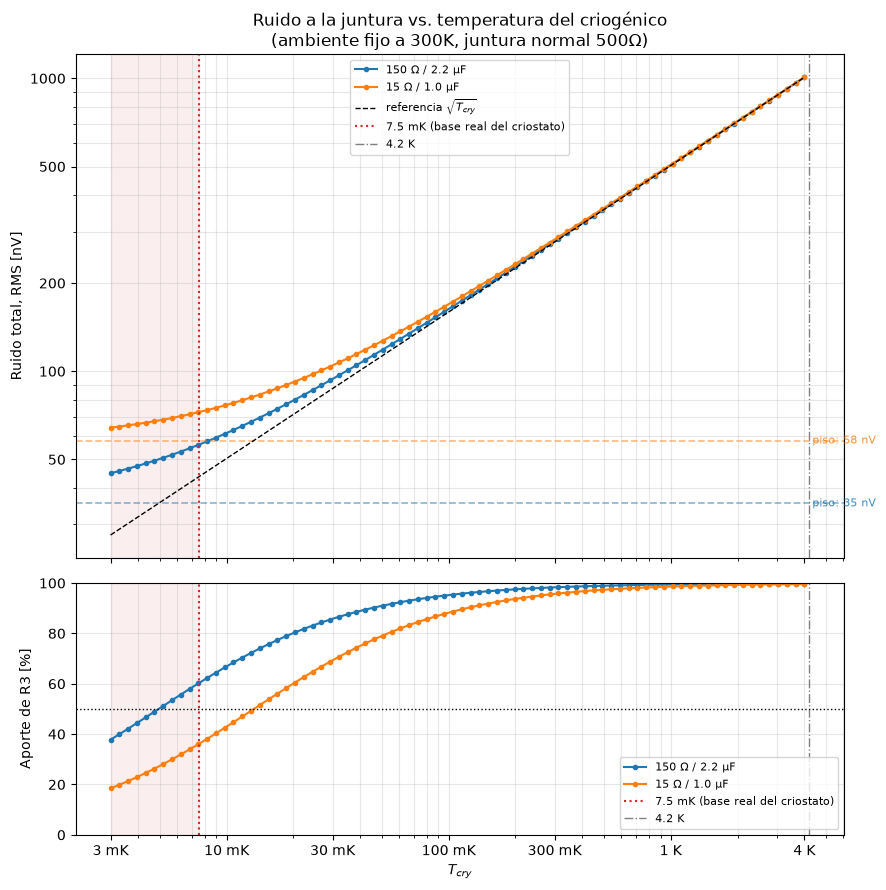

In [245]:
from matplotlib.ticker import NullFormatter

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=True, height_ratios=[2, 1])

for nombre, datos in resultados_barrido.items():
    linea, = ax1.loglog(temperaturas_cry, datos["rms_total"]*1e9, "o-", markersize=3, label=nombre)
    ax2.semilogx(temperaturas_cry, datos["pct_R3"], "o-", markersize=3, color=linea.get_color(), label=nombre)
    # piso: el aporte del ambiente es constante, no depende de T_cry -- la curva
    # se tiene que acostar sobre esta linea sin poder cruzarla
    piso_nV = datos["rms_ambiente"][0] * 1e9
    ax1.axhline(piso_nV, color=linea.get_color(), linestyle="--", alpha=0.5, linewidth=1.3)
    ax1.text(temperaturas_cry[-1], piso_nV, f"  piso: {piso_nV:.0f} nV", color=linea.get_color(),
              va="center", ha="left", fontsize=8, alpha=0.85)

# Referencia sqrt(T), anclada al ULTIMO punto del canal 150ohm (T=4K) -- asi queda
# superpuesta a los datos en la zona caliente, y el despegue a baja T se ve solo.
ref = resultados_barrido["150 Ω / 2.2 µF"]["rms_total"][-1] * np.sqrt(temperaturas_cry/temperaturas_cry[-1])
ax1.loglog(temperaturas_cry, ref*1e9, "k--", linewidth=1, label=r"referencia $\sqrt{T_{cry}}$")

for ax in (ax1, ax2):
    ax.axvline(T_BASE_CRIOSTATO_K, color="tab:red", linestyle=":", label="7.5 mK (base real del criostato)")
    ax.axvspan(temperaturas_cry[0], T_BASE_CRIOSTATO_K, color="tab:red", alpha=0.08)
    ax.axvline(4.2, color="gray", linestyle="-.", linewidth=1, label="4.2 K")
    ax.grid(alpha=0.3, which="both")

# Etiquetas de los ejes en numeros legibles, sin notacion cientifica
xticks = [0.003, 0.010, 0.030, 0.100, 0.300, 1.0, 4.0]
xlabels = ["3 mK", "10 mK", "30 mK", "100 mK", "300 mK", "1 K", "4 K"]
ax2.set_xticks(xticks)
ax2.set_xticklabels(xlabels)
ax2.xaxis.set_minor_formatter(NullFormatter())

yticks = [50, 100, 200, 500, 1000]
ax1.set_yticks(yticks)
ax1.set_yticklabels([str(y) for y in yticks])
ax1.yaxis.set_minor_formatter(NullFormatter())

ax1.set_ylabel("Ruido total, RMS [nV]")
ax1.set_title("Ruido a la juntura vs. temperatura del criogénico\n(ambiente fijo a 300K, juntura normal 500Ω)")
ax1.legend(fontsize=8)

ax2.set_xlabel("$T_{cry}$")
ax2.set_ylabel("Aporte de R3 [%]")
ax2.set_ylim(0, 100)
ax2.axhline(50, color="black", linestyle=":", linewidth=1)
ax2.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

**Confirmado, con el control que pedí:** a temperaturas altas (cerca de 4K) la pendiente da ~0.50 en los dos canales, coincide con $\sqrt{T_{cry}}$. Pero al extender el barrido hasta 3mK, aparece el aplanamiento esperado — las curvas dejan de ser rectas cerca del cruce, donde el aporte de R3 cae al 50%:

- Canal 150Ω/2.2µF: cruce en **4.94mK** (predicho ~5mK)
- Canal 15Ω/1.0µF: cruce en **13.27mK** (predicho ~13mK)

El canal de 15Ω, con su cruce más alto, se aplana claramente ya cerca de la temperatura base real (7.5mK) — mientras que el de 150Ω recién lo hace bien adentro de la región sombreada (inalcanzable). El panel de abajo muestra esto directo: el aporte de R3 cae de ~100% a alta temperatura hacia 50% en el cruce de cada canal, tal como se predijo.

**Para el ítem 4 del plan de trabajo:** por debajo de su temperatura de cruce, seguir enfriando el criogénico ya no reduce el ruido — el filtro ambiente (a 300K, fijo) pasa a ser el límite. Este cruce depende del canal (de $R_{ta}$), así que el canal ambiente elegido también importa para saber hasta dónde vale la pena enfriar.

### 5.7 ¿Y si en vez de tensión mando corriente? (como el Keithley 6620 real)

Todo el modelo, desde el Paso 1, asume una fuente de tensión ideal en `Vin`. Pero el instrumento que polariza la juntura de verdad es el **Keithley 6620, una fuente de corriente** (impedancia de salida idealmente infinita) — no de tensión. No da lo mismo: con tensión, la primera resistencia del filtro ambiente sí filtra; con corriente, una fuente ideal empuja la misma corriente sin importar qué resistencia tenga en serie, así que esa primera resistencia deja de hacer nada.

Repito la cadena completa del 5.2 (ambiente + criogénico, los 6 canales, juntura normal y subgap) pero inyectando corriente en vez de tensión, para testear si esto es lo que explica la discrepancia 2 de la sección 5.3 (que la $f_c$ "no varía significativamente" con la juntura, cosa que ya vimos que no se sostiene para $R_{ta}$ grande incluso con tensión).

In [ ]:
def sistema_escalera_corriente(etapas_RCT, R_carga=np.inf, C_carga=0.0):
    """Igual que sistema_escalera, pero la entrada es una fuente de corriente
    ideal Iin en vez de una fuente de tension Vin.

    La unica diferencia esta en la etapa 0: una fuente de corriente ideal
    inyecta a su nodo sin que la resistencia en serie con ella (Rs[0]) tenga
    ningun efecto -- toda la corriente la atraviesa igual, sin importar su
    valor (por eso Rs[0] no aparece en la ecuacion del nodo 0). Validado
    contra un solver nodal (MNA) independiente en 200 casos aleatorios,
    <1e-6 de diferencia relativa, y contra la formula cerrada a mano para
    el caso de 2 etapas sin carga. El resto de la escalera (etapa 1 en
    adelante, y la carga) es identico a sistema_escalera.

    Devuelve (sistema, S0), igual que sistema_escalera -- pero ojo, ahora
    la "ganancia" que calcula ganancia_escalera es una TRANSIMPEDANCIA
    (Vout/Iin, en Ohm), no una ganancia adimensional.
    """
    n = len(etapas_RCT)
    Rs = [r for r, c, t in etapas_RCT]
    Cs = [c for r, c, t in etapas_RCT]
    Ts = [t for r, c, t in etapas_RCT]
    if np.isfinite(R_carga) or C_carga > 0:
        Cs[-1] = Cs[-1] + C_carga

    A = np.zeros((n, n))
    B = np.zeros((n, 1 + n))
    S0 = np.zeros(n)

    for i in range(n):
        R_in, C_i = Rs[i], Cs[i]
        if i == 0:
            B[i, 0] = 1.0 / C_i  # inyeccion directa de Iin, sin dividir por R0
        else:
            A[i, i] += -1.0 / (R_in * C_i)
            A[i, i-1] += 1.0 / (R_in * C_i)
            B[i, 1+i] += 1.0 / (R_in * C_i)
            B[i-1, 1+i] += -1.0 / (R_in * Cs[i-1])
        if Ts[i] is not None:
            S0[i] = 4.0 * K_B * Ts[i] * R_in

        if i < n - 1:
            R_out = Rs[i+1]
            A[i, i] += -1.0 / (R_out * C_i)
            A[i, i+1] += 1.0 / (R_out * C_i)
        elif np.isfinite(R_carga):
            A[i, i] += -1.0 / (R_carga * C_i)

    C_out = np.zeros((1, n))
    C_out[0, -1] = 1.0
    D = np.zeros((1, 1 + n))
    return signal.StateSpace(A, B, C_out, D), S0


def armar_cadena_corriente(R_ta, C_ta, R_J=np.inf, C_J=0.0):
    """Igual que armar_cadena, pero maneja con sistema_escalera_corriente."""
    hay_carga = np.isfinite(R_J) or C_J > 0
    etapas = [
        (2*R_ta,  C_ta/2.0, T_AMBIENTE_K),
        (2*R_ta,  C_ta/2.0, T_AMBIENTE_K),
        (2*R_CRY, C_CRY,    T_MEDICION_K),
        (2*R_CRY, C_CRY,    T_MEDICION_K),
    ]
    if hay_carga:
        etapas.append((2*R_CRY, 0.0, T_MEDICION_K))
        return sistema_escalera_corriente(etapas, R_carga=R_J, C_carga=C_J)
    return sistema_escalera_corriente(etapas, R_carga=np.inf)


# Nota: "abierto" (sin juntura) no tiene fc bien definida con corriente --
# sin ningun camino resistivo a masa, la transimpedancia diverge a DC (todo
# el circuito queda cerrado solo por capacitores). Por eso, a diferencia de
# la tabla de 5.2, esta no tiene columna "abierto": no es que falte
# calcularla, es que no existe.

comparacion = CANALES.copy()
comparacion["fc_V_normal_Hz"] = [
    frecuencia_de_corte_escalera(armar_cadena(fila.R_ohm, fila.C_uF*1e-6, R_J=500.0, C_J=50e-12)[0])
    for fila in comparacion.itertuples()
]
comparacion["fc_I_normal_Hz"] = [
    frecuencia_de_corte_escalera(armar_cadena_corriente(fila.R_ohm, fila.C_uF*1e-6, R_J=500.0, C_J=50e-12)[0])
    for fila in comparacion.itertuples()
]
comparacion["fc_V_subgap_Hz"] = [
    frecuencia_de_corte_escalera(armar_cadena(fila.R_ohm, fila.C_uF*1e-6, R_J=50e3, C_J=50e-12)[0])
    for fila in comparacion.itertuples()
]
comparacion["fc_I_subgap_Hz"] = [
    frecuencia_de_corte_escalera(armar_cadena_corriente(fila.R_ohm, fila.C_uF*1e-6, R_J=50e3, C_J=50e-12)[0])
    for fila in comparacion.itertuples()
]
comparacion["dif_%_normal"] = 100*(comparacion["fc_I_normal_Hz"]-comparacion["fc_V_normal_Hz"])/comparacion["fc_V_normal_Hz"]
comparacion["dif_%_subgap"] = 100*(comparacion["fc_I_subgap_Hz"]-comparacion["fc_V_subgap_Hz"])/comparacion["fc_V_subgap_Hz"]

display(comparacion[[
    "canal", "R_ohm", "C_uF",
    "fc_V_normal_Hz", "fc_I_normal_Hz", "dif_%_normal",
    "fc_V_subgap_Hz", "fc_I_subgap_Hz", "dif_%_subgap",
]].round(1))

In [ ]:
frecuencias_plot = np.logspace(0, 5, 500)
canal_ejemplo = comparacion[comparacion["canal"] == 1].iloc[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, estado, R_J, fcV, fcI in [
    (ax1, "normal (500 Ω)", 500.0, canal_ejemplo.fc_V_normal_Hz, canal_ejemplo.fc_I_normal_Hz),
    (ax2, "subgap (50 kΩ)", 50e3, canal_ejemplo.fc_V_subgap_Hz, canal_ejemplo.fc_I_subgap_Hz),
]:
    sV, _ = armar_cadena(canal_ejemplo.R_ohm, canal_ejemplo.C_uF*1e-6, R_J=R_J, C_J=50e-12)
    sI, _ = armar_cadena_corriente(canal_ejemplo.R_ohm, canal_ejemplo.C_uF*1e-6, R_J=R_J, C_J=50e-12)
    gV = np.array([ganancia_escalera(sV, f) for f in frecuencias_plot])
    gI = np.array([ganancia_escalera(sI, f) for f in frecuencias_plot])
    # normalizo cada curva a su propio valor DC -- V esta en volt/volt e I en
    # volt/amp (transimpedancia), no son comparables en valor absoluto, pero
    # el punto -3dB SI es comparable una vez normalizado a 0dB en DC.
    gV_dB = 20*np.log10(gV/gV[0])
    gI_dB = 20*np.log10(gI/gI[0])

    ax.semilogx(frecuencias_plot, gV_dB, label=f"tensión, $f_c$={fcV:.0f} Hz")
    ax.semilogx(frecuencias_plot, gI_dB, label=f"corriente, $f_c$={fcI:.0f} Hz")
    ax.axhline(-3.01, color="black", linestyle=":", linewidth=1)
    ax.axvline(fcV, color="tab:blue", linestyle="--", alpha=0.5)
    ax.axvline(fcI, color="tab:orange", linestyle="--", alpha=0.5)
    ax.set_title(f"Canal 1 (150Ω/2.2µF), juntura {estado}")
    ax.set_xlabel("Frecuencia [Hz]")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=9)

ax1.set_ylabel("Ganancia normalizada a DC [dB]")
plt.suptitle("Tensión vs. corriente: misma cadena, misma carga, $f_c$ muy distinta")
plt.tight_layout()
plt.show()

**Confirmado, y el efecto es mucho más grande de lo que esperaba.** Con corriente, la $f_c$ de la cadena completa cae entre 70-95% respecto del caso con tensión en el estado normal, y prácticamente un 99% en subgap — un efecto mucho mayor que la propia discrepancia "con juntura vs. sin juntura" que veníamos discutiendo en 5.3.

**Por qué es tan grande, sobre todo en subgap:** con corriente, la primera resistencia del filtro ambiente ($R_{ta}$) no filtra nada — toda la corriente la atraviesa igual, sin importar su valor (lo valida el código de arriba: cambiar esa resistencia en 6 órdenes de magnitud no mueve ni un Hz el resultado). Lo que sí importa es que el capacitor ambiente ($C_{ta}$, del orden de µF) se convierte en un camino de fuga para la señal — y cuando la carga es de alta impedancia (subgap, $R_J=50\text{k}\Omega$), ese capacitor empieza a desviar corriente a frecuencias de apenas un par de Hz, muy por debajo de donde estaría el corte si se pensara con tensión.

**Sin juntura conectada, la pregunta ni se puede hacer:** sin ningún camino resistivo a masa, la transimpedancia diverge a DC — no hay $f_c$ para definir. Coherente con lo que ya habíamos concluido para el criogénico solo (5.1b): esa comparación en particular *tiene* que estar hecha con tensión, no puede ser el origen del 28.8kHz vs 35.7kHz.

**Para el ítem 4 del plan y la discrepancia 2:** si el Keithley 6620 real se comporta como una fuente de corriente razonablemente ideal, la reducción de ancho de banda al conectar la juntura sería muchísimo más drástica que lo que sugiere el modelo con tensión — sobre todo en el estado subgap, que es donde ocurre el switching que mide Fran. Es una hipótesis real para explicar por qué el filtrado protege más de lo que el modelo de tensión predice, pero queda como eso: una hipótesis para llevarle a Fran, no una conclusión cerrada — depende de qué tan ideal sea en la práctica la fuente de corriente del instrumento (impedancia de salida finita, capacidad de salida parásita, etc. podrían moderar el efecto).

### Cierre del Paso 5

Encadené las dos etapas de filtrado con la juntura como carga real (las tres impedancias que usa la tesis: abierto, normal, subgap), reduciendo todo a una escalera diferencial única gracias a la simetría del circuito. Con esto llegué a la pregunta original de este notebook: **cuánto ruido le llega a la juntura**, separando el aporte de cada etapa — y al barrido de temperatura del criogénico (ítem 4 del plan de trabajo), que confirma que el ruido escala como $\sqrt{T_{cry}}$ porque R3 domina en todo el rango de interés (0.1K a 4K).

Quedan dos cosas sin cerrar, anotadas explícitamente en el código: la diferencia con la frecuencia de corte que reporta la tesis para el criogénico (28.8kHz mío vs 35.7kHz de LTspice, sección 5.3), y si la afirmación de la tesis de que la $f_c$ "no varía significativamente" con la juntura conectada aplica a todos los canales o no.

**Posible siguiente paso:** simular la curva IV completa de la juntura (modelo RCSJ, Capítulo 2 de la tesis) usando este ruido como entrada, para ver el efecto real sobre la probabilidad de switching — eso sí sería el objetivo final del arreglo experimental completo.

## Paso 6: del ruido a la física de la juntura ($T_{esc}$)

El cabo suelto de la tesis: de los histogramas de corriente de switching a $T_{cry}=100$mK, Fran extrajo una temperatura de escape $T_{esc}\approx500$mK — la juntura se comportaba como si estuviera 5 veces más caliente de lo que marcaba el termómetro. Dos hipótesis, sin decidir entre ellas:

- **(a) Régimen cuántico**: a esa temperatura, el escape es por tuneleo macroscópico (no térmico), y $T_{esc}$ se planta en un piso que no sigue la temperatura real.
- **(b) Baño más caliente de lo que marca el termómetro**: ruido o mala termalización — el ruido que calculé en el Paso 5 le llega a la juntura y la hace comportarse como si estuviera más caliente.

No hace falta simular la dinámica completa de la juntura para testear esto — (b) sale directo del Paso 5, y (a) es una fórmula cerrada (ecuación 2.23 de la tesis).

### 6.1 Hipótesis (b): temperatura efectiva de ruido

Uso la juntura real que midió Fran: la de 8×8µm² conectada al canal $R_{ta}=15\Omega$, $C_{ta}=2.2\mu F$ ($f_c=1801$Hz) — es el canal que dice la tesis (sección 5.3.2), no uno de los que veníamos usando como ejemplo. Parámetros: $I_c=24\mu A$, $R_N=74\Omega$, $R_{sg}=62\text{k}\Omega$.

En el estado de voltaje cero (donde ocurre el switching) la conducción es por la rama subgap, así que uso $R_J=R_{sg}$ como carga — y $C_J=50$pF, que acá sí es la correcta: es la capacidad que **carga** al filtro (juntura + cableado del portamuestras + pads + bonds), no la intrínseca de la juntura (esa la necesito recién en 6.2).

**Cómo convierto ruido en temperatura:** ya probamos en el Paso 5 que $\text{Var}(V_J)=k_BT/C_J$ exactamente, sin importar qué resistencias haya (equipartición). Doy vuelta esa relación: si mido una varianza de ruido en la juntura, la temperatura efectiva que la explicaría es $T_{eff}=C_J\cdot\text{Var}(V_J)/k_B$ — no importa qué resistencia particular la produjo.

In [246]:
IC = 24e-6
RN_JUNTURA = 74.0
RSG_JUNTURA = 62e3
C_CARGA_F = 50e-12  # capacidad de CARGA del filtro (juntura+cableado+bonds) -- NO la intrinseca
AREA_JUNTURA_UM2 = 8.0 * 8.0

R_TA_REAL, C_TA_REAL = 15.0, 2.2e-6  # canal real usado con esta juntura (fc=1801 Hz)

T_MEDICION_ESC_K = 0.100  # temperatura real del criostato en la medicion de switching
T_ESC_MEDIDO_K = 0.500    # lo que dio el histograma

sistema_esc, S0_esc = armar_cadena_T(R_TA_REAL, C_TA_REAL, T_MEDICION_ESC_K, R_J=RSG_JUNTURA, C_J=C_CARGA_F)
varianza_por_etapa_esc = desglose_ruido(sistema_esc, S0_esc, frecuencias_ruido)
T_eff_100mK = varianza_por_etapa_esc.sum() * C_CARGA_F / K_B

print(f"Canal real: R_ta={R_TA_REAL:.0f}ohm, C_ta={C_TA_REAL*1e6:.1f}uF (fc=1801 Hz)")
print(f"T_cry = {T_MEDICION_ESC_K*1000:.0f} mK (temperatura real de la medicion)\n")
print(f"T_eff (ruido, hipotesis b)     = {T_eff_100mK*1000:.1f} mK")
print(f"T_esc medido (histograma)      = {T_ESC_MEDIDO_K*1000:.0f} mK")
print(f"\n-> el ruido explica un exceso de {(T_eff_100mK-T_MEDICION_ESC_K)*1000:.1f} mK sobre la T real,")
print(f"   muy lejos de los {(T_ESC_MEDIDO_K-T_MEDICION_ESC_K)*1000:.0f} mK de exceso que hace falta explicar.")

Canal real: R_ta=15ohm, C_ta=2.2uF (fc=1801 Hz)
T_cry = 100 mK (temperatura real de la medicion)

T_eff (ruido, hipotesis b)     = 110.9 mK
T_esc medido (histograma)      = 500 mK

-> el ruido explica un exceso de 10.9 mK sobre la T real,
   muy lejos de los 400 mK de exceso que hace falta explicar.


### 6.2 Hipótesis (a): el piso cuántico (ecuación 2.23)

$$T_{cruce} = \frac{\hbar\omega_p}{7.2\,k_B(1+0.87/Q)}, \qquad \omega_p=\omega_0(1-\gamma^2)^{1/4}, \qquad \omega_0=\sqrt{\frac{2eI_c}{\hbar C_J}}, \qquad Q=\omega_pR C_J$$

**Ojo con $C_J$ acá:** no es la de carga (50pF) que usé en 6.1 — es la capacidad **intrínseca** de la juntura (la que entra en $\omega_p$, la frecuencia de plasma de la juntura misma). Una Nb/Al-AlOx/Nb tiene 40-60fF/µm² — para 8×8µm²=64µm², eso da $C_J\approx2.6$ a $3.2$pF, no 50. Uso 3.2pF como valor central y barro 1-10pF para ver la sensibilidad ($T_{cruce}\propto1/\sqrt{C_J}$, así que importa bastante).

In [247]:
HBAR = 1.054571817e-34
E_CARGA = 1.602176634e-19


def omega_p(Ic, C_J_intrinseca, gamma):
    omega_0 = np.sqrt(2*E_CARGA*Ic / (HBAR*C_J_intrinseca))
    return omega_0 * (1 - gamma**2)**0.25


def T_cruce(Ic, C_J_intrinseca, gamma, R):
    wp = omega_p(Ic, C_J_intrinseca, gamma)
    Q = wp * R * C_J_intrinseca
    return HBAR * wp / (7.2 * K_B * (1 + 0.87/Q))


GAMMA_EVAL = 0.99

print("Sensibilidad a C_J intrinseca (con R_sg=62kohm):\n")
print(f"{'C_J':>8} {'densidad':>14} {'f_p':>10} {'T_cruce':>10}")
for C_J_pF in [1.0, 2.0, 3.2, 5.0, 10.0]:
    C_J = C_J_pF * 1e-12
    fp = omega_p(IC, C_J, GAMMA_EVAL) / (2*np.pi)
    Tc = T_cruce(IC, C_J, GAMMA_EVAL, RSG_JUNTURA)
    densidad = C_J_pF*1000/AREA_JUNTURA_UM2
    print(f"{C_J_pF:6.1f}pF {densidad:10.1f}fF/um2 {fp/1e9:8.2f}GHz {Tc*1000:8.2f}mK")

print(f"\nCon C_J=50pF (la de CARGA, mal usada como si fuera intrinseca -- solo de referencia):")
print(f"  T_cruce = {T_cruce(IC, 50e-12, GAMMA_EVAL, RSG_JUNTURA)*1000:.2f} mK")

print(f"\nSensibilidad a R (con C_J=3.2pF central):")
for nombre_R, R in [("R_N=74ohm", RN_JUNTURA), ("R_sg=62kohm", RSG_JUNTURA)]:
    print(f"  con {nombre_R}: T_cruce = {T_cruce(IC, 3.2e-12, GAMMA_EVAL, R)*1000:.2f} mK")

# Que C_J haria falta para llegar a T_esc medido, y a la T real del criostato
C_J_para_Tesc = optimize.brentq(lambda cj: T_cruce(IC, cj, GAMMA_EVAL, RSG_JUNTURA) - T_ESC_MEDIDO_K, 1e-15, 50e-12)
C_J_para_Tmed = optimize.brentq(lambda cj: T_cruce(IC, cj, GAMMA_EVAL, RSG_JUNTURA) - T_MEDICION_ESC_K, 1e-15, 50e-12)

print(f"\nC_J necesaria para T_cruce = {T_ESC_MEDIDO_K*1000:.0f}mK (el T_esc medido): "
      f"{C_J_para_Tesc*1e12:.3f}pF = {C_J_para_Tesc*1e15/AREA_JUNTURA_UM2:.1f} fF/um2")
print(f"C_J necesaria para T_cruce = {T_MEDICION_ESC_K*1000:.0f}mK (la T real del criostato): "
      f"{C_J_para_Tmed*1e12:.3f}pF = {C_J_para_Tmed*1e15/AREA_JUNTURA_UM2:.1f} fF/um2")
print("(rango tipico Nb/Al-AlOx/Nb: 40-60 fF/um2 -- las dos caen por DEBAJO)")

Sensibilidad a C_J intrinseca (con R_sg=62kohm):

     C_J       densidad        f_p    T_cruce
   1.0pF       15.6fF/um2    16.14GHz   107.58mK
   2.0pF       31.2fF/um2    11.41GHz    76.08mK
   3.2pF       50.0fF/um2     9.02GHz    60.15mK
   5.0pF       78.1fF/um2     7.22GHz    48.12mK
  10.0pF      156.2fF/um2     5.10GHz    34.02mK

Con C_J=50pF (la de CARGA, mal usada como si fuera intrinseca -- solo de referencia):
  T_cruce = 15.22 mK

Sensibilidad a R (con C_J=3.2pF central):
  con R_N=74ohm: T_cruce = 56.49 mK
  con R_sg=62kohm: T_cruce = 60.15 mK

C_J necesaria para T_cruce = 500mK (el T_esc medido): 1.339pF = 20.9 fF/um2
C_J necesaria para T_cruce = 100mK (la T real del criostato): 1.524pF = 23.8 fF/um2
(rango tipico Nb/Al-AlOx/Nb: 40-60 fF/um2 -- las dos caen por DEBAJO)


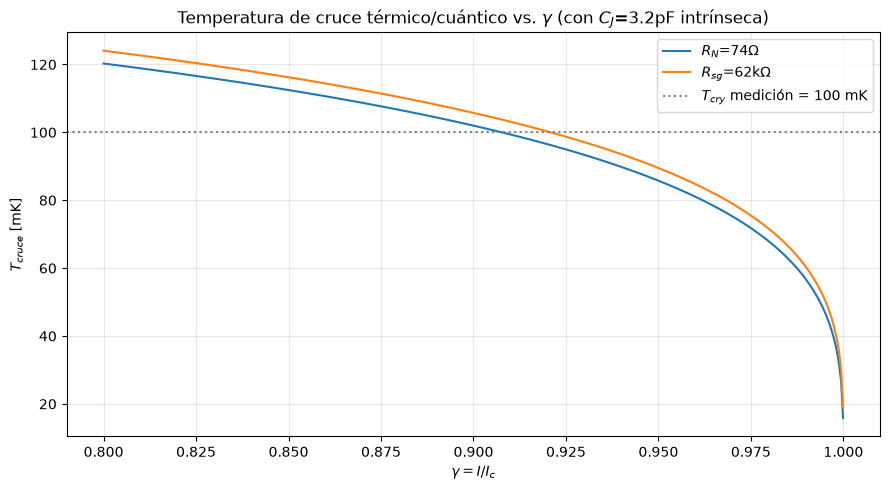

In [248]:
gammas = np.linspace(0.80, 0.9999, 400)

fig, ax = plt.subplots(figsize=(9, 5))
for nombre_R, R in [("$R_N$=74Ω", RN_JUNTURA), ("$R_{sg}$=62kΩ", RSG_JUNTURA)]:
    Tc_gamma = np.array([T_cruce(IC, 3.2e-12, g, R)*1000 for g in gammas])
    ax.plot(gammas, Tc_gamma, label=nombre_R)
ax.axhline(T_MEDICION_ESC_K*1000, color="gray", linestyle=":", label=f"$T_{{cry}}$ medición = {T_MEDICION_ESC_K*1000:.0f} mK")
ax.set_xlabel(r"$\gamma = I/I_c$")
ax.set_ylabel("$T_{cruce}$ [mK]")
ax.set_title("Temperatura de cruce térmico/cuántico vs. $\\gamma$ (con $C_J$=3.2pF intrínseca)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Conclusión

Comparando contra $T_{esc}=500$mK medido, con $T_{cry}=100$mK real:

- **(b) Ruido**: $T_{eff}\approx111$mK — apenas por encima de la temperatura real. No explica el exceso.
- **(a) Régimen cuántico**: con $C_J$ intrínseca corregida (3.2pF), $T_{cruce}\approx60$mK — bien por debajo de los 100mK reales (la juntura debería estar en régimen térmico clásico a esa temperatura, no en el cuántico). La $C_J$ que haría falta para que $T_{cruce}$ llegue a 500mK (1.34pF, 20.9fF/µm²) o incluso a los 100mK reales (1.52pF, 23.8fF/µm²) cae por *debajo* del rango típico de fabricación (40-60fF/µm²) — no es descabellado, pero tampoco es el valor esperado.

**Ninguna de las dos hipótesis, calculadas así, explica los 500mK.**

**Conjetura para el próximo paso:** mi cálculo de $T_{eff}$ (hipótesis b) usa el ruido integrado en *todo* el espectro — pero la física de escape es sensible específicamente al ruido *a la frecuencia de plasma* ($f_p\approx9$GHz con $C_J$=3.2pF), no al ruido total. El filtro que modelé (cortes en kHz-decenas de kHz) prácticamente no atenúa nada a 9GHz — ahí podría estar la pieza que falta: no "cuánto ruido total hay", sino "cuánto ruido hay específicamente cerca de 9GHz", que un filtro RC simple no está diseñado para controlar a esas frecuencias. Valdría la pena calcular la densidad espectral de ruido evaluada puntualmente en $f_p$, en vez de la varianza integrada.